In [1]:
# imports

# tsa
import numpy as np
import pandas as pd
import datetime as dt

# data fetching
import yfinance as yf
import requests


# ds
from typing import Dict, Tuple, Union, Optional, List

# stats
import statsmodels.api as sm
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.stattools import coint, adfuller, kpss

from scipy.optimize import minimize_scalar

# visualisation
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

import seaborn as sns

### 1. data fetching and cleaning
dropnas, keep only  weekdays for tokenised (24 hr) markets to match (micro) gold futures 

In [2]:
# data fetching params - yfinance

# start end time for data download
start = "2020-01-01" # xaut started trading in 2020
end = dt.datetime.today().strftime('%Y-%m-%d') # today

assets = ['PAXG-USD', 'XAUT-USD', 'MGC=F', 'GC=F']

In [3]:
# download historical price data - yahoo finace
data = {}
for asset in assets:
    df = yf.download(asset, start=start, end=end)
    df.columns = [col[0] for col in df.columns] # comes as a tuple (field, asset)
    data[asset] = df

# Align data on common dates - only weekdays cos of futures data
data_weekdays = {}
common_dates = set.intersection(*[set(df.index) for df in data.values()])
for asset in assets:
    data_weekdays[asset] = data[asset].loc[data[asset].index.isin(common_dates)].sort_index()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### 2. correlation and cointegration analysis

In [4]:
# correlation and cointegration matrices 
corr_matrix = np.zeros((len(assets), len(assets)))
coint_matrix = np.zeros((len(assets), len(assets)))

for i in range(len(assets)):
    for j in range(i+1, len(assets)):
        asset_i = data_weekdays[assets[i]]['Close']
        asset_j = data_weekdays[assets[j]]['Close']
        
        # Correlation
        corr_matrix[i, j] = asset_i.corr(asset_j)
        corr_matrix[j, i] = corr_matrix[i, j]


        # Engle-Granger (augmented) cointegration test
        score, pvalue, _ = coint(asset_i, asset_j, trend='c', method='aeg', autolag='aic')
        coint_matrix[i, j] = pvalue
        coint_matrix[j, i] = pvalue

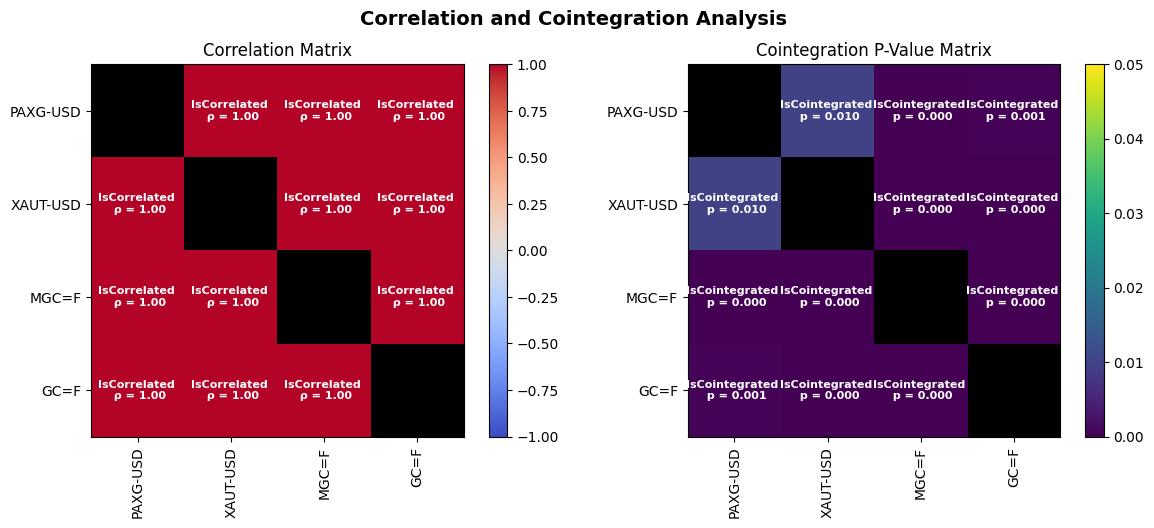

In [5]:
# corr coint plots
plt.subplots(1, 2, figsize=(12, 5))

# correlation Matrix with black zeros
plt.subplot(1, 2, 1)
plt.title('Correlation Matrix')
# create custom colormap where 0 values are black

corr_cmap = plt.cm.coolwarm.copy()
corr_cmap.set_bad('black')  # set NaN/masked values to black

# mask zero values to make them black
corr_masked = np.ma.masked_where(np.abs(corr_matrix) < 1e-10, corr_matrix)
im1 = plt.imshow(corr_masked, cmap=corr_cmap, vmin=-1, vmax=1)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and abs(corr_matrix[i, j]) >= 0.7: # check for strong correlation
            plt.text(j, i, f"IsCorrelated \n ρ = {corr_matrix[i, j]:.2f}", ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')

plt.colorbar(im1)  

# cointegration Matrix with text annotations
coint_cmap = plt.cm.viridis.copy()
coint_cmap.set_bad('black')  # Set values below vmin to white
coint_masked = np.ma.masked_where(coint_matrix == 0, coint_matrix)  # Mask non-significant values
plt.subplot(1, 2, 2)
plt.title('Cointegration P-Value Matrix')
im2 = plt.imshow(coint_masked, cmap=coint_cmap, vmin=0, vmax=0.05)
plt.xticks(range(len(assets)), assets, rotation=90)
plt.yticks(range(len(assets)), assets)
# Add text annotations for significant cointegration
for i in range(len(assets)):
    for j in range(len(assets)):
        if i != j and coint_matrix[i, j] < 0.05:  # Skip diagonal and check significance
            plt.text(j, i, f'IsCointegrated \n p = {coint_matrix[i, j]:.3f}', ha='center', va='center', 
                    color='white', fontsize=8, weight='bold')
        
plt.colorbar(im2)

plt.suptitle('Correlation and Cointegration Analysis', fontsize=14, fontweight='bold', y=1)
plt.savefig("corr-coint-matrices_white.png", dpi=300, bbox_inches="tight", transparent=False)
plt.tight_layout()
fig = plt.gcf()

for ax in fig.axes:
    ax.tick_params(axis='both', colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')
    for spine in ax.spines.values():
        spine.set_color('white')
for txt in fig.texts:
    txt.set_color('white')

fig.savefig("corr-coint-matrices_black.png", dpi=300, bbox_inches="tight", transparent=True)

# use black styling for in notebook display
for ax in fig.axes:
    ax.tick_params(axis='both', colors='black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    ax.title.set_color('black')
    for spine in ax.spines.values():
        spine.set_color('black')

for txt in fig.texts:
    txt.set_color('black')


plt.rcdefaults()
plt.show()




plot of correlation and cointegration show high correlation (1 for all pairwise comparisons) and engle granger p values < 0.05, can reject H0 of no cointegration, residuals are stationary.

### 3. initial parameter settings
windows for rolling calculations and train/test split dates

In [6]:
# initial parameters
# validation periods
train_end = '2023-12-31'
train_start = min(df.index.min() for df in data_weekdays.values()).strftime('%Y-%m-%d')
test_end = max(df.index.max() for df in data_weekdays.values()).strftime('%Y-%m-%d')

window = 20 # one trading month - weekday data 5 * 4 = 20
beta_window = 20 # 6 months of trading days - weekday data 5 * 24 = 120 more stable beta estimates
windows = [5, 10, 20, 50, 100]


### 4. spread and beta computation

helper function definition

In [7]:
def compute_spread(data, asset1, asset2, beta=True, rolling_window=window,
                   min_periods=20, debug=True):
    # ONE shared, de-duplicated, sorted index -> no positional/label drift
    j = (data[asset1][['Close']].rename(columns={'Close': 'y'})
         .join(data[asset2][['Close']].rename(columns={'Close': 'x'}), how='inner'))
    j = j[~j.index.duplicated(keep='first')].sort_index()
    y, x = j['y'], j['x']

    if not beta:
        spread = (y - x).rename('spread')
        return spread, pd.Series(1.0, index=spread.index, name='beta')

    # rolling OLS slope (with intercept) == cov(y,x)/var(x) — vectorised, exact
    beta_series = (y.rolling(rolling_window, min_periods=min_periods).cov(x)
                   / x.rolling(rolling_window, min_periods=min_periods).var()).rename('beta')
    spread = (y - beta_series * x)
    spread.name = f'{asset1}_{asset2}_spread_rolling_beta_{rolling_window}d'

    if debug:
        v = beta_series.dropna()
        print(f"Rolling Beta {asset1}-{asset2} (w={rolling_window}): mean {v.mean():.4f} "
              f"std {v.std():.4f} min {v.min():.4f} max {v.max():.4f} "
              f"valid {len(v)}/{len(beta_series)}")
    return spread, beta_series

In [8]:
# compute spreads w/ and w/o beta adjustments

spreads = {
    'PAXG-XAUT': compute_spread(data,'PAXG-USD', 'XAUT-USD', beta=False)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', beta=False)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', beta=False)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', beta=False)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', beta=False)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', beta=False)[0],
}

spreads_beta = {
    'PAXG-XAUT': compute_spread(data,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}

Rolling Beta PAXG-USD-XAUT-USD (w=20): mean 0.9524 std 0.1920 min -0.0904 max 1.8371 valid 2375/2394
Rolling Beta PAXG-USD-GC=F (w=20): mean 0.9267 std 0.1696 min 0.1475 max 1.5984 valid 1630/1649
Rolling Beta XAUT-USD-GC=F (w=20): mean 0.9228 std 0.1208 min 0.2574 max 1.3061 valid 1630/1649
Rolling Beta PAXG-USD-MGC=F (w=20): mean 0.9241 std 0.1789 min 0.1094 max 1.5721 valid 1630/1649
Rolling Beta XAUT-USD-MGC=F (w=20): mean 0.9213 std 0.1244 min 0.3341 max 1.3061 valid 1630/1649
Rolling Beta GC=F-MGC=F (w=20): mean 0.9976 std 0.0342 min 0.8444 max 1.1081 valid 1630/1649


In [9]:
# check for and drop NaNs from each spread series

print(f"NaN counts before dropping from naive spread series: {[series.isna().sum() for series in spreads.values()]}")
spreads = {name: series.dropna() for name, series in spreads.items()}

print(f"NaN counts before dropping: {[series.isna().sum() for series in spreads_beta.values()]}")
spreads_beta = {name: series.dropna() for name, series in spreads_beta.items()}

NaN counts before dropping from naive spread series: [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
NaN counts before dropping: [np.int64(19), np.int64(19), np.int64(19), np.int64(19), np.int64(19), np.int64(19)]


normalize spreads

In [10]:
# spread normalisation - zscores
# z-scores
rolling_zscore = {
    name: (series - series.rolling(window=window).mean()) / series.rolling(window=window).std()
    for name, series in spreads.items()
}

exp_zscore = {
    name: (series - series.ewm(span=window, adjust=False).mean()) / series.ewm(span=window, adjust=False).std()
    for name, series in spreads.items()
}

rolling_zscore_beta = {
    name: (series - series.rolling(window=window).mean()) / series.rolling(window=window).std()
    for name, series in spreads_beta.items()
}

exp_zscore_beta = {
    name: (series - series.ewm(span=window, adjust=False).mean()) / series.ewm(span=window, adjust=False).std()
    for name, series in spreads_beta.items()
}

# add z-score columns directly into the existing spreads dict
for name, series in spreads.items():
    spreads[name] = series.to_frame(name='spread')
    spreads[name]['rolling_zscore'] = rolling_zscore[name]
    spreads[name]['exp_zscore'] = exp_zscore[name]

for name, series in spreads_beta.items():
    spreads_beta[name] = series.to_frame(name='spread')
    spreads_beta[name]['rolling_zscore'] = rolling_zscore_beta[name]
    spreads_beta[name]['exp_zscore'] = exp_zscore_beta[name]
  

In [11]:
# split by pairs
paxg_xaut_spread = spreads['PAXG-XAUT']
paxg_xau_spread = spreads['PAXG-XAU']
xaut_xau_spread = spreads['XAUT-XAU']
paxg_xaut_spread_beta = spreads_beta['PAXG-XAUT']
paxg_xau_spread_beta = spreads_beta['PAXG-XAU']
xaut_xau_spread_beta = spreads_beta['XAUT-XAU']

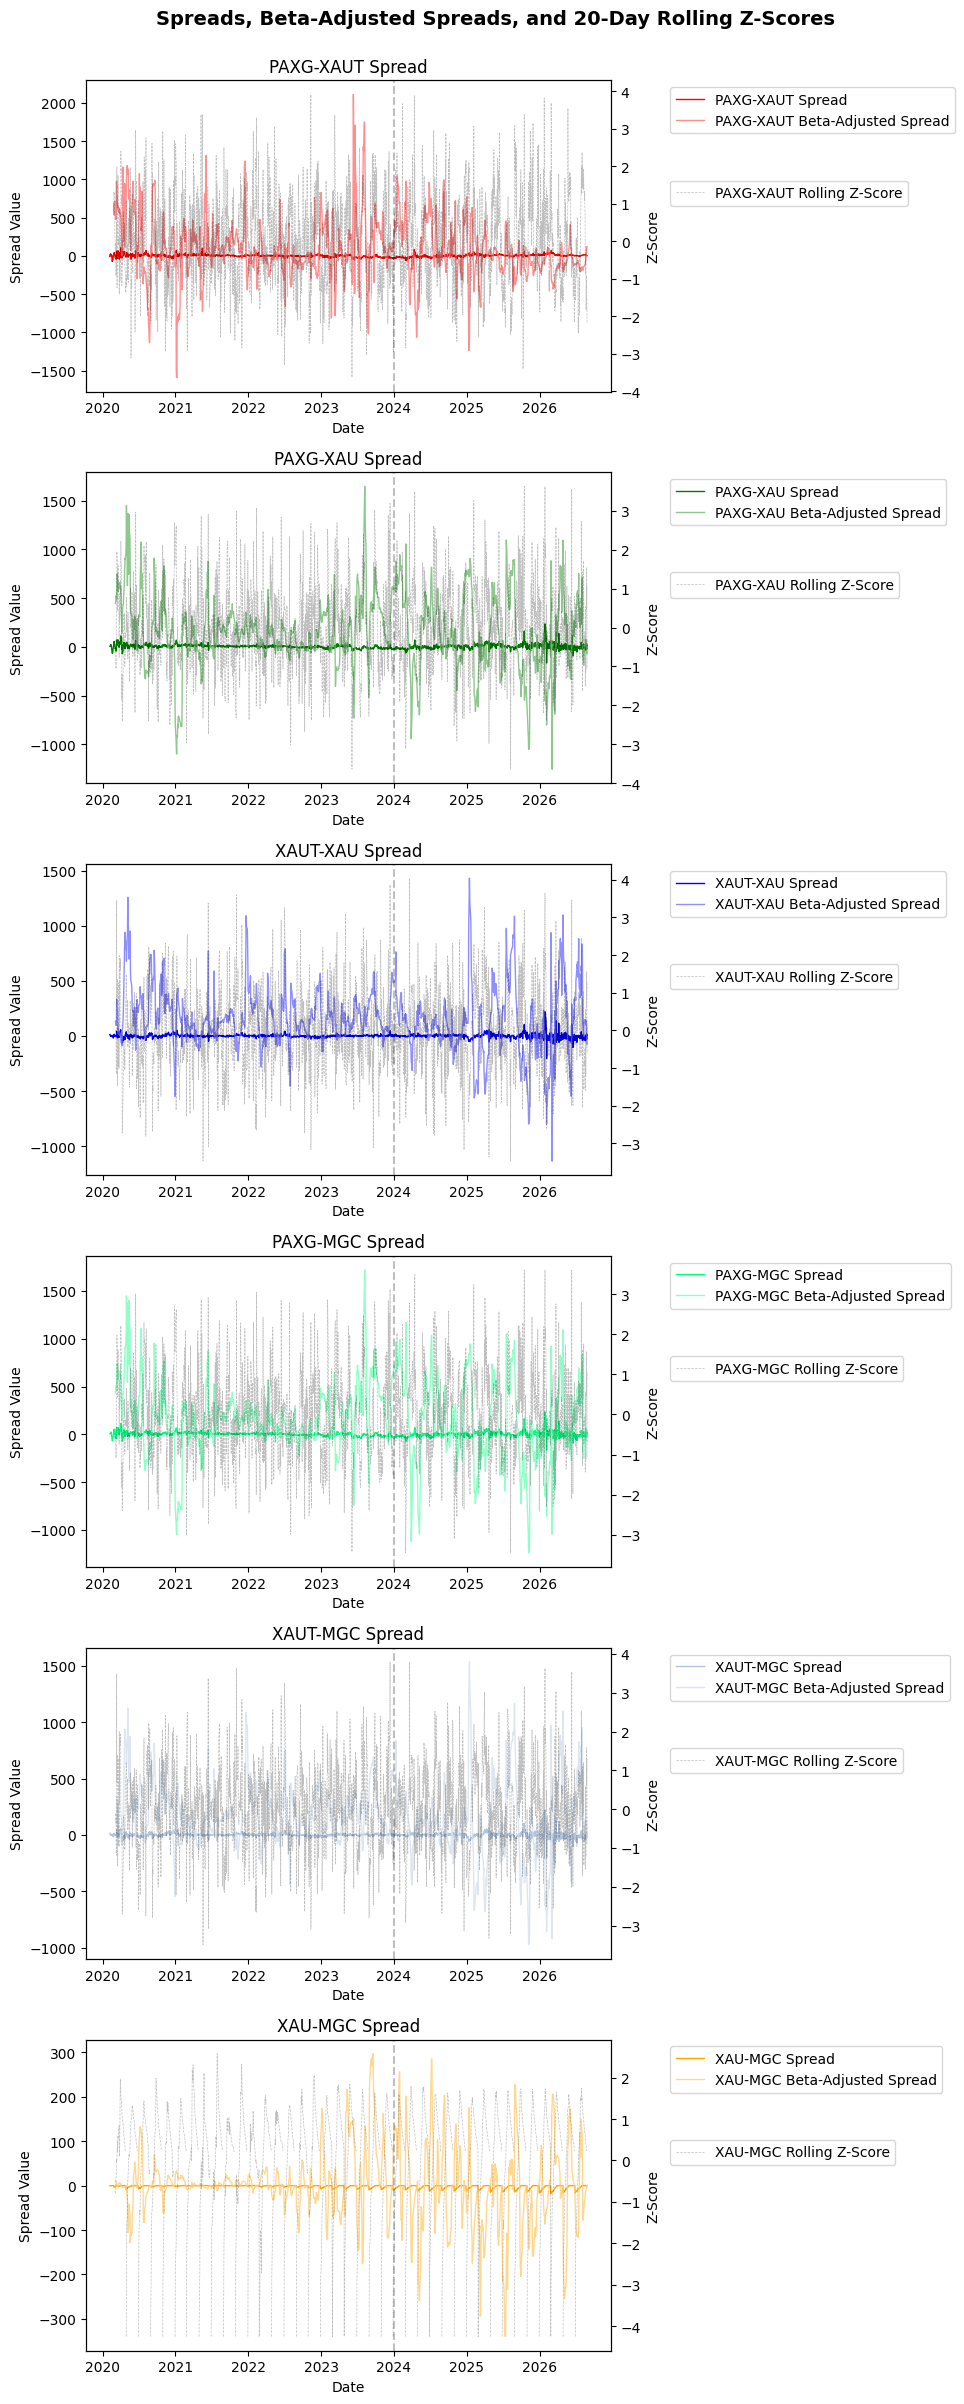

In [12]:
# plot of spreads, rolling z-scores, and beta-adjusted spreads
names = ['PAXG-XAUT', 'PAXG-XAU', 'XAUT-XAU', 'PAXG-MGC', 'XAUT-MGC', 'XAU-MGC']
fig, axs = plt.subplots(len(names), 1, figsize=(10, 4*len(names)))#, sharex=True)

colors = ['red', 'green', 'blue', 'springgreen', 'lightsteelblue', 'orange']



for i, name in enumerate(names):
    # Original Spread
    axs[i].plot(spreads[name]['spread'], label=f'{name} Spread', color = colors[i], alpha=1, linewidth=1)
    axs[i].set_title(f'{name} Spread')
    axs[i].legend(loc='upper left', bbox_to_anchor=(1.1, 1))
    axs[i].set_xlabel('Date')
    axs[i].set_ylabel('Spread Value')
    
    # Beta-adjusted spread with lighter shade of the same base color
    base = np.array(mcolors.to_rgb(colors[i]))
    lighter_color = tuple(base + (1 - base) * 0.45)  # increase toward white
    axs[i].plot(
        spreads_beta[name]['spread'],
        color=lighter_color,
        label=f'{name} Beta-Adjusted Spread',
        alpha=0.8,
        linewidth=1
    )
    axs[i].legend(loc='upper left', bbox_to_anchor=(1.1, 1))

    # Z-Scores
    twin = axs[i].twinx()
    twin.plot(spreads[name]['rolling_zscore'], label=f'{name} Rolling Z-Score', color='black', alpha=0.25, linestyle='--', linewidth=0.5)
    twin.legend(loc='upper left', bbox_to_anchor=(1.1, 0.7))
    twin.set_ylabel('Z-Score')

    axs[i].axvline(pd.Timestamp(train_end),color='black',linestyle="--",alpha=0.25)
plt.suptitle(f'Spreads, Beta-Adjusted Spreads, and {window}-Day Rolling Z-Scores', fontsize=14, fontweight='bold', y= 1)
plt.tight_layout()

# # save fig
# plt.savefig('spread_bspread_zscore_plot_white.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()



### 5. train/test splitting

In [13]:
# signal generation params
window = 20
entry_threshold = 2
exit_threshold = 0.15

beta_adj = False
asset_A = 'XAUT-USD' # xaut usd
asset_B = 'GC=F' # gold futures



# Time Considerations for validation split
train_start = min([data_weekdays[asset].index.min().strftime('%Y-%m-%d') for asset in assets])
train_end = '2023-12-31' 
test_start = '2026-01-01'
test_end = None #dt.datetime.now().strftime('%Y-%m-%d')

In [14]:
# train/test split by date

# truncate each asset's dataframe (no overlap: test is strictly after train_end)
data_train = {a: d.loc[d.index <= train_end] for a, d in data_weekdays.items()}
data_test  = {a: d.loc[d.index >  train_end] for a, d in data_weekdays.items()}

full_spreads = {
    'PAXG-XAUT': compute_spread(data_weekdays, 'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=False)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', rolling_window=beta_window, beta=False)[0],
}

full_spreads_beta = {
    'PAXG-XAUT': compute_spread(data_weekdays,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_weekdays,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_weekdays,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_weekdays,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_weekdays,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_weekdays,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}


train_spreads = {
    'PAXG-XAUT': compute_spread(data_train,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=False)[0],
    'PAXG-XAU': compute_spread(data_train,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-XAU': compute_spread(data_train,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'PAXG-MGC': compute_spread(data_train,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-MGC': compute_spread(data_train,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAU-MGC': compute_spread(data_train,'GC=F', 'MGC=F', rolling_window=beta_window, beta=False)[0],
}

train_spreads_beta = {
    'PAXG-XAUT': compute_spread(data_train,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_train,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_train,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_train,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_train,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_train,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}

test_spreads = {
    'PAXG-XAUT': compute_spread(data_test,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=False)[0],
    'PAXG-XAU': compute_spread(data_test,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-XAU': compute_spread(data_test,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=False)[0],
    'PAXG-MGC': compute_spread(data_test,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAUT-MGC': compute_spread(data_test,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=False)[0],
    'XAU-MGC': compute_spread(data_test,'GC=F', 'MGC=F', rolling_window=beta_window, beta=False)[0],
}

test_spreads_beta = {
    'PAXG-XAUT': compute_spread(data_test,'PAXG-USD', 'XAUT-USD',rolling_window=beta_window, beta=True)[0],
    'PAXG-XAU': compute_spread(data_test,'PAXG-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-XAU': compute_spread(data_test,'XAUT-USD', 'GC=F', rolling_window=beta_window, beta=True)[0],
    'PAXG-MGC': compute_spread(data_test,'PAXG-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAUT-MGC': compute_spread(data_test,'XAUT-USD', 'MGC=F', rolling_window=beta_window, beta=True)[0],
    'XAU-MGC': compute_spread(data_test,'GC=F', 'MGC=F', rolling_window=beta_window, beta=True)[0],
}

# # spread on each side (compute_spread returns (spread, beta) in both branches)
# train_spread, train_beta = compute_spread(data_train, asset_A, asset_B, beta=beta_adj, debug=False)
# test_spread,  test_beta  = compute_spread(data_test,  asset_A, asset_B, beta=beta_adj, debug=False)

# keep the rest of the notebook running on train by default
spreads, spreads_beta = train_spreads, train_spreads_beta

Rolling Beta PAXG-USD-XAUT-USD (w=20): mean 0.9759 std 0.1596 min 0.2010 max 1.7617 valid 1630/1649
Rolling Beta PAXG-USD-GC=F (w=20): mean 0.9267 std 0.1696 min 0.1475 max 1.5984 valid 1630/1649
Rolling Beta XAUT-USD-GC=F (w=20): mean 0.9228 std 0.1208 min 0.2574 max 1.3061 valid 1630/1649
Rolling Beta PAXG-USD-MGC=F (w=20): mean 0.9241 std 0.1789 min 0.1094 max 1.5721 valid 1630/1649
Rolling Beta XAUT-USD-MGC=F (w=20): mean 0.9213 std 0.1244 min 0.3341 max 1.3061 valid 1630/1649
Rolling Beta GC=F-MGC=F (w=20): mean 0.9976 std 0.0342 min 0.8444 max 1.1081 valid 1630/1649
Rolling Beta PAXG-USD-XAUT-USD (w=20): mean 0.9666 std 0.1849 min 0.2010 max 1.7617 valid 962/981
Rolling Beta PAXG-USD-GC=F (w=20): mean 0.9076 std 0.1808 min 0.1475 max 1.5984 valid 962/981
Rolling Beta XAUT-USD-GC=F (w=20): mean 0.8966 std 0.1234 min 0.2574 max 1.3061 valid 962/981
Rolling Beta PAXG-USD-MGC=F (w=20): mean 0.9020 std 0.1855 min 0.1094 max 1.5721 valid 962/981
Rolling Beta XAUT-USD-MGC=F (w=20): mean

### 6. stationarity testing - adf & kpss - on full dataset

In [15]:
# stationarity testing - adf, kpss
#*todo - handle interpolatoin warnings.

adf_stationarity = {}
kpss_stationarity = {}

for name, series in full_spreads.items():
    adf_result = adfuller(series.dropna())
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    
    adf_stationarity[name] = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical Values': adf_result[4]
    }
    
    kpss_stationarity[name] = {
        'KPSS Statistic': kpss_result[0],
        'p-value': kpss_result[1],
        'Critical Values': kpss_result[3]
    }

adf_stationarity_beta = {}
kpss_stationarity_beta = {}

for name, series in full_spreads_beta.items():
    adf_result = adfuller(series.dropna())
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    
    adf_stationarity_beta[name] = {
        'ADF Statistic': adf_result[0],
        'p-value': adf_result[1],
        'Critical Values': adf_result[4]
    }
    
    kpss_stationarity_beta[name] = {
        'KPSS Statistic': kpss_result[0],
        'p-value': kpss_result[1],
        'Critical Values': kpss_result[3]
    }
    
for name, result in adf_stationarity.items():
    print(f"{name}: ADF Statistic = {result['ADF Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)")
    else:
        print(f"   => {name} is likely non-stationary (Fail to reject null hypothesis of non-stationarity - time series has a unit root)")
    
for name, result in kpss_stationarity.items():
    print(f"{name}: KPSS Statistic = {result['KPSS Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} is likely non-stationary (Reject null hypothesis of stationarity)")
    else:
        print(f"   => {name} is likely stationary (Fail to reject null hypothesis of stationarity)")

for name, result in adf_stationarity_beta.items():
    print(f"{name} (Beta Adjusted): ADF Statistic = {result['ADF Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} (Beta Adjusted) is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)")
    else:
        print(f"   => {name} (Beta Adjusted) is likely non-stationary (Fail to reject null hypothesis of non-stationarity - time series has a unit root)")

for name, result in kpss_stationarity_beta.items():
    print(f"{name} (Beta Adjusted): KPSS Statistic = {result['KPSS Statistic']:.4f}, p-value = {result['p-value']:.4f}")
    for key, value in result['Critical Values'].items():
        print(f"   Critical Value ({key}): {value:.4f}")
    if result['p-value'] < 0.05:
        print(f"   => {name} (Beta Adjusted) is likely non-stationary (Reject null hypothesis of stationarity)")
    else:
        print(f"   => {name} (Beta Adjusted) is likely stationary (Fail to reject null hypothesis of stationarity)")

C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:9: InterpolationWarning: The test 

PAXG-XAUT: ADF Statistic = -3.7107, p-value = 0.0040
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => PAXG-XAUT is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
PAXG-XAU: ADF Statistic = -4.7046, p-value = 0.0001
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => PAXG-XAU is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
XAUT-XAU: ADF Statistic = -5.7917, p-value = 0.0000
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => XAUT-XAU is likely stationary (Reject null hypothesis of non-stationarity - time series has a unit root)
PAXG-MGC: ADF Statistic = -5.3044, p-value = 0.0000
   Critical Value (1%): -3.4344
   Critical Value (5%): -2.8633
   Critical Value (10%): -2.5677
   => PAXG-MGC is likely stationary (Reject null hypothesis of non-st

C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:28: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\2702020452.py:28: InterpolationWarning: The t

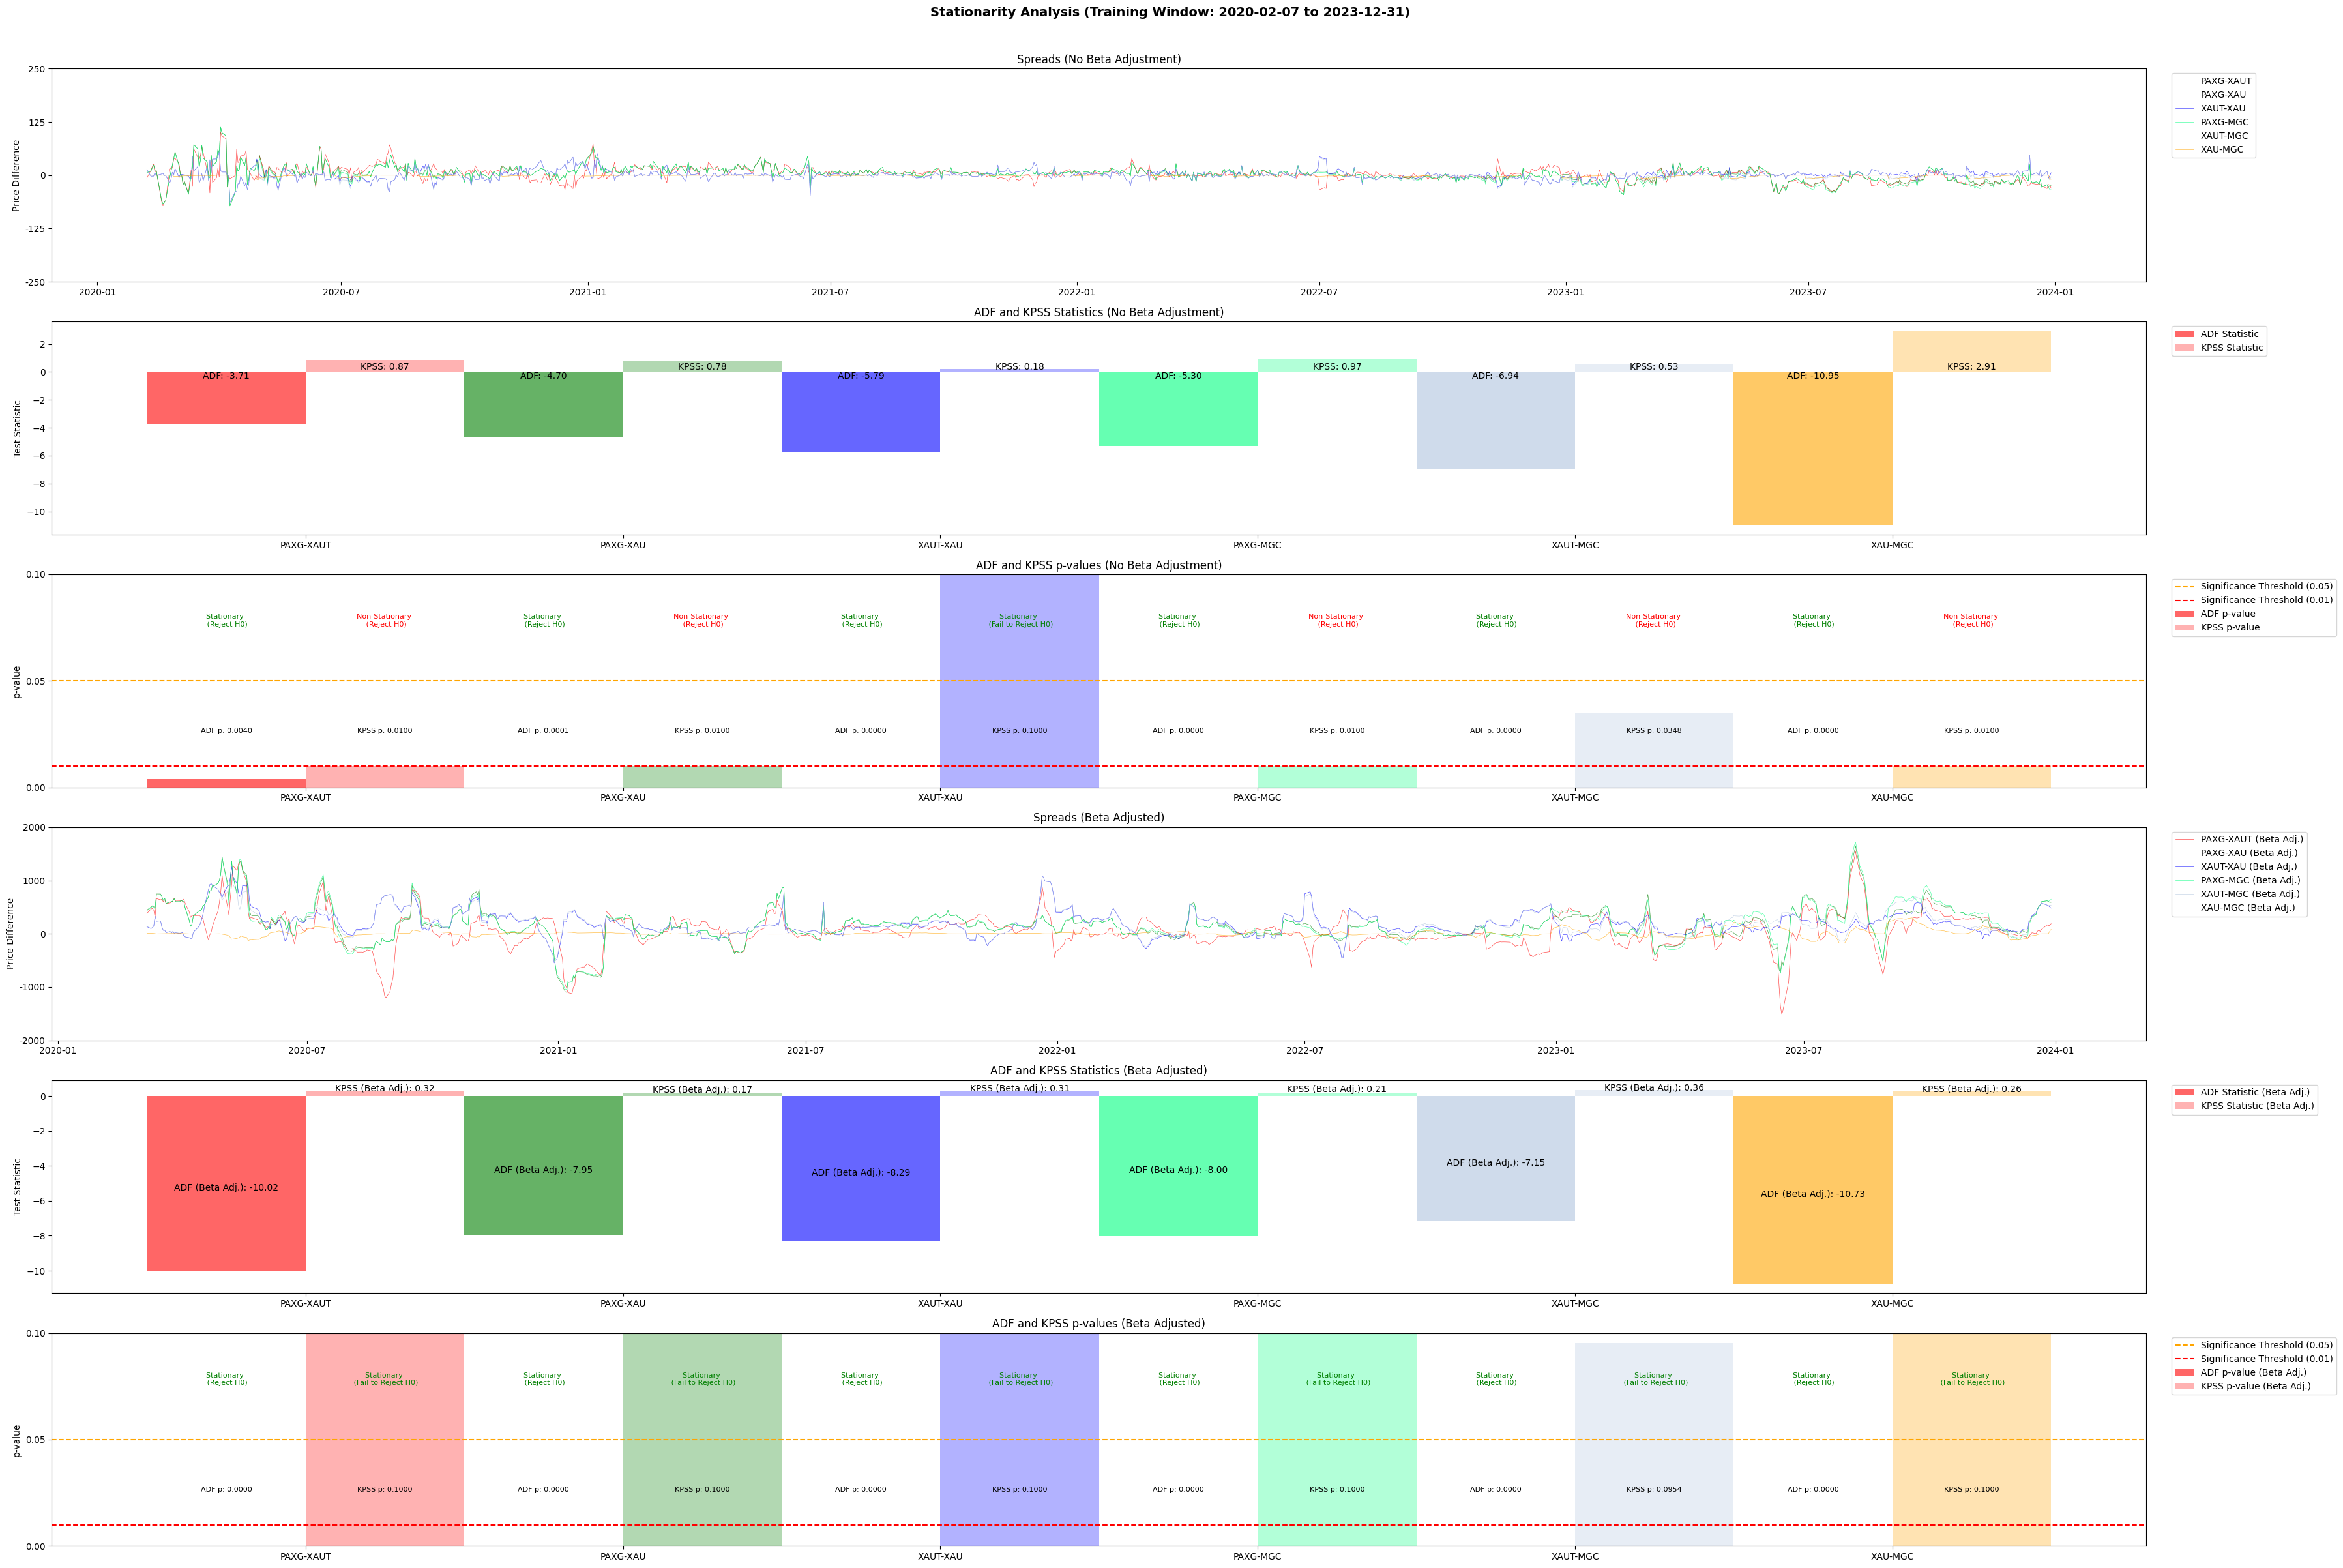

In [16]:
# stationarity plots - p values vs critical values
# *todo change bar chart legend to be neutral blaclk grey 

# Create consistent color scheme for all spreads
colors = ['red', 'green', 'blue', 'springgreen', 'lightsteelblue', 'orange']
spread_names = list(spreads.keys())

fig, axs = plt.subplots(len(spread_names), 1, figsize=(6*len(spread_names), 4*len(spread_names)))#, sharex=True)

# Plot spreads without beta adjustment
for i, (name, series) in enumerate(spreads.items()):
    axs[0].plot(series, color=colors[i], label=name, alpha=0.7, linewidth=0.5)

# Plot ADF and KPSS statistics for regular spreads
bar_width = 0.5
x_positions = np.arange(len(spread_names))

# ADF Statistics (No Beta Adjustment)
adf_values = [adf_stationarity[name]['ADF Statistic'] for name in spread_names]
adf_critical_values = [[adf_stationarity[name]['Critical Values'][cv] for cv in ['1%', '5%', '10%']] for name in spread_names]
axs[1].bar(x_positions - bar_width/2, adf_values, bar_width, 
           color=colors[:len(spread_names)], alpha=0.6, label='ADF Statistic')

for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, adf_values)):
    axs[1].text(pos, 0, f"ADF: {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')
    added_labels = set()
    # for i, (pos, crit_vals) in enumerate(zip(x_positions - bar_width/2, adf_critical_values)):
    #     for cv_label, cv_value in zip(['1%', '5%', '10%'], crit_vals):
    #         color = 'darkslategray' if cv_label == '1%' else 'darkturquoise' if cv_label == '5%' else 'paleturquoise'
    #         label = f'ADF Critical Value ({cv_label})' if cv_label not in added_labels else None
    #         axs[1].hlines(cv_value, pos - bar_width/2, pos + bar_width/2, colors=color, linestyles='--')# label=label)
    #         added_labels.add(cv_label)

# KPSS Statistics (No Beta Adjustment)
kpss_values = [kpss_stationarity[name]['KPSS Statistic'] for name in spread_names]
kpss_critical_values = [[kpss_stationarity[name]['Critical Values'][cv] for cv in ['10%', '5%', '2.5%', '1%']] for name in spread_names]
axs[1].bar(x_positions + bar_width/2, kpss_values, bar_width, 
           color=colors[:len(spread_names)], alpha=0.3, label='KPSS Statistic')

for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, kpss_values)):
    axs[1].text(pos, 0, f"KPSS: {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')

    # for i, (pos, crit_vals) in enumerate(zip(x_positions + bar_width/2, kpss_critical_values)):
    #     for cv_label, cv_value in zip(['10%', '5%', '2.5%', '1%'], crit_vals):
    #         color = 'darkslategray' if cv_label == '10%' else 'darkturquoise' if cv_label == '5%' else 'cadetblue' if cv_label == '2.5%' else 'paleturquoise'
    #         label = f'KPSS Critical Value ({cv_label})' if cv_label not in added_labels else None
    #         axs[1].hlines(cv_value, pos - bar_width/2, pos + bar_width/2, colors=color, linestyles='--')#, label=label)
    #         added_labels.add(cv_label)


# p-values for ADF and KPSS tests
axs[2].bar(x_positions - bar_width/2, [adf_stationarity[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.6, label='ADF p-value')
axs[2].bar(x_positions + bar_width/2, [kpss_stationarity[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.3, label='KPSS p-value')
axs[2].axhline(0.05, color='orange', linestyle='--', label='Significance Threshold (0.05)')
axs[2].axhline(0.01, color='red', linestyle='--', label='Significance Threshold (0.01)')
# ADF p-value annotations (p < 0.05 = Stationary)
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, [adf_stationarity[name]['p-value'] for name in spread_names])):
    axs[2].text(pos, 0.025, f"ADF p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[2].text(pos, 0.075, f"{'Stationary \n (Reject H0)' if val < 0.05 else 'Non-Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='green' if val < 0.05 else 'red')
# KPSS p-value annotations (p < 0.05 = Non-Stationary) 
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, [kpss_stationarity[name]['p-value'] for name in spread_names])):
    axs[2].text(pos, 0.025, f"KPSS p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[2].text(pos, 0.075, f"{'Non-Stationary \n (Reject H0)' if val < 0.05 else 'Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='red' if val < 0.05 else 'green')



# Plot spreads with beta adjustment
for i, (name, series) in enumerate(spreads_beta.items()):
    axs[3].plot(series, color=colors[i], label=name + ' (Beta Adj.)', linewidth=0.5, alpha=0.7)

# ADF Statistics (Beta Adjustment)
adf_values_beta = [adf_stationarity_beta[name]['ADF Statistic'] for name in spread_names]
axs[4].bar(x_positions - bar_width/2, adf_values_beta, bar_width, 
           color=colors[:len(spread_names)], alpha=0.6, label='ADF Statistic (Beta Adj.)')
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, adf_values_beta)):
    axs[4].text(pos, val/2, f"ADF (Beta Adj.): {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')
# KPSS Statistics (Beta Adjustment)
kpss_values_beta = [kpss_stationarity_beta[name]['KPSS Statistic'] for name in spread_names]
axs[4].bar(x_positions + bar_width/2, kpss_values_beta, bar_width, 
           color=colors[:len(spread_names)], alpha=0.3, label='KPSS Statistic (Beta Adj.)')
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, kpss_values_beta)):
    axs[4].text(pos, val/2, f"KPSS (Beta Adj.): {val:.2f}", ha='center', va='bottom' if val >= 0 else 'top')


# p-values for ADF and KPSS tests with Beta Adjustment
axs[5].bar(x_positions - bar_width/2, [adf_stationarity_beta[name]['p-value'] for name in spread_names],
           width=bar_width, color=colors[:len(spread_names)], alpha=0.6, label='ADF p-value (Beta Adj.)')
axs[5].bar(x_positions + bar_width/2, [kpss_stationarity_beta[name]['p-value'] for name in spread_names],
              width=bar_width, color=colors[:len(spread_names)], alpha=0.3, label='KPSS p-value (Beta Adj.)')
axs[5].axhline(0.05, color='orange', linestyle='--', label='Significance Threshold (0.05)')
axs[5].axhline(0.01, color='red', linestyle='--', label='Significance Threshold (0.01)')
# ADF p-value annotations (p < 0.05 = Stationary)
for i, (pos, val) in enumerate(zip(x_positions - bar_width/2, [adf_stationarity_beta[name]['p-value'] for name in spread_names])):
    axs[5].text(pos, 0.025, f"ADF p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[5].text(pos, 0.075, f"{'Stationary \n (Reject H0)' if val < 0.05 else 'Non-Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='green' if val < 0.05 else 'red')
# KPSS p-value annotations (p < 0.05 = Non-Stationary)
for i, (pos, val) in enumerate(zip(x_positions + bar_width/2, [kpss_stationarity_beta[name]['p-value'] for name in spread_names])):
    axs[5].text(pos, 0.025, f"KPSS p: {val:.4f}", ha='center', va='bottom', fontsize=8)
    axs[5].text(pos, 0.075, f"{'Non-Stationary \n (Reject H0)' if val < 0.05 else 'Stationary \n (Fail to Reject H0)'}", ha='center', va='bottom', fontsize=8, color='red' if val < 0.05 else 'green')

# Set x-axis labels for bar charts
for ax in [axs[1], axs[2], axs[4], axs[5]]:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(spread_names)

# Set titles and labels
axs[0].set_title('Spreads (No Beta Adjustment)')
axs[0].set_ylabel('Price Difference', position=(0, 0.5))
axs[0].set_ylim(-250, 250)
yticks = np.arange(-250, 300, 125)
axs[0].set_yticks(yticks)
axs[0].set_yticklabels([f"{y:.0f}" for y in yticks])


axs[1].set_title('ADF and KPSS Statistics (No Beta Adjustment)')
axs[1].set_ylabel('Test Statistic')

axs[2].set_title('ADF and KPSS p-values (No Beta Adjustment)')
axs[2].set_ylabel('p-value')

axs[3].set_title('Spreads (Beta Adjusted)')
axs[3].set_ylabel('Price Difference')
axs[3].set_ylim(-2000, 2000)
yticks = np.arange(-2000, 2250, 1000)
axs[3].set_yticks(yticks)
axs[3].set_yticklabels([f"{y:.0f}" for y in yticks])

axs[4].set_title('ADF and KPSS Statistics (Beta Adjusted)')
axs[4].set_ylabel('Test Statistic')

axs[5].set_title('ADF and KPSS p-values (Beta Adjusted)')
axs[5].set_ylabel('p-value')

for i in 2,5:
    axs[i].set_ylim(0, 0.1)
    yticks = np.arange(0, 0.15, 0.05)
    axs[i].set_yticks(yticks)
    axs[i].set_yticklabels([f"{y:.2f}" for y in yticks])

# Add legends
axs[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[2].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[3].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[4].legend(bbox_to_anchor=(1.01, 1), loc='upper left')
axs[5].legend(bbox_to_anchor=(1.01, 1), loc='upper left')

plt.suptitle(f'Stationarity Analysis (Training Window: {train_start} to {train_end})', fontsize=14, fontweight='bold', y=1)
plt.tight_layout(rect=[0, 0, 1, 0.99])  # Leave 1% space at top for suptitle
plt.show()



XAUT-XAU and XAUT-MGC show stationarity in both ADF (low p values, reject H0 non stationary) and KPSS (high p values, fail to reject H0 stationary) tests, will proceed with XAUT-XAU spread for further analysis.

from here on out, any reference to spread1 and spread2, will refer to the XAUT-XAU and XAUT-MGC non beta-adjusted spreads respectively.

will work on beta adjust spreads after the testing framework is established.

In [17]:
# more params, see above
spread1 = compute_spread(data_weekdays, 'XAUT-USD', 'GC=F', beta=False, rolling_window=beta_window)[0]
spread2 = compute_spread(data_weekdays, 'XAUT-USD', 'MGC=F', beta=False, rolling_window=beta_window)[0]

df_1 = data_weekdays['XAUT-USD'].copy()
df_2 = data_weekdays['GC=F'].copy()#

vol_window = window #21 # 21 trading days ~ 1 month, using same as z-score window for consistency

### 7. bid-ask spread estimation - corwin-schultz (2012)

In [18]:
def corwin_schultz_spread(
    df: pd.DataFrame,
    high_col: str = "High",
    low_col: str = "Low",
    close_col: Optional[str] = "Close",   # REQUIRED for the overnight adjustment
    overnight_adjust: bool = True,
    agg: str = "rolling",                 # 'rolling' | 'monthly' | 'none'
    window: int = 21,                     # trading days for rolling agg
    min_obs: int = 12,                    # CS require >=12 valid days
    hl_ratio_max: float = 8.0,            # CS reject High/Low > 8
    floor_negative: bool = True,          # MSPREAD_0: floor daily spread at 0 BEFORE averaging
    bps: bool = False,
    pips: bool = False,
    pip_size: float = 0.01,
    absolute: bool = False,
    lag: bool = False,                    # True only if using as a signal known at t-1
) -> pd.Series:
    """
    Corwin & Schultz (2012) high-low spread WITH the original price-cleaning
    and the overnight-return adjustment. Returns spread as a fraction of mid
    (bps/absolute optional). Without close prices the estimator keeps the
    gap-driven downward bias that makes it fall in volatility.
    """
    if bps and absolute:
        raise ValueError("choose one of bps / absolute")
    k = 3.0 - 2.0 * np.sqrt(2.0)

    out = df[[high_col, low_col]].copy()
    out.columns = ["H", "L"]
    out = out.sort_index()                # continuous index; DO NOT dropna before shift(1)

    if close_col is not None and close_col in df.columns:
        out["C"] = df[close_col].reindex(out.index).abs()
    elif overnight_adjust:
        raise ValueError("overnight_adjust=True needs close_col; pass it or "
                         "set overnight_adjust=False (not recommended).")

    H = out["H"].astype(float)
    L = out["L"].astype(float)

    # ---- 1. clean bad bars -> NaN ---------------------------------------
    bad = (H <= 0) | (L <= 0) | (H == L) | (L > H) | (H / L > hl_ratio_max)
    H, L = H.mask(bad), L.mask(bad)

    # ---- 2. overnight-return adjustment (the fix for the vol inversion) --
    # Slide the whole day's range so it connects to the prior close, so the
    # 2-day range (gamma) no longer absorbs the overnight gap.
    if overnight_adjust:
        c_lag = out["C"].shift(1)
        have  = c_lag.notna() & (c_lag > 0) & H.notna() & L.notna()
        gap_up = have & (c_lag < L)        # opened above prior close
        gap_dn = have & (c_lag > H)        # opened below prior close
        H2_, L2_ = H.copy(), L.copy()
        H2_ = H2_.mask(gap_up, H - (L - c_lag)); L2_ = L2_.mask(gap_up, c_lag)
        H2_ = H2_.mask(gap_dn, c_lag);           L2_ = L2_.mask(gap_dn, L + (c_lag - H))
        H, L = H2_, L2_

    # ---- 3. beta, gamma, alpha, spread ----------------------------------
    log_hl = np.log(H / L)
    beta   = log_hl**2 + log_hl.shift(1)**2
    H_2d   = pd.concat([H, H.shift(1)], axis=1).max(axis=1)
    L_2d   = pd.concat([L, L.shift(1)], axis=1).min(axis=1)
    gamma  = np.log(H_2d / L_2d)**2

    alpha  = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
    spread = 2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))     # signed fraction of mid

    daily = spread.clip(lower=0) if floor_negative else spread  # clip preserves NaN

    # ---- 4. units at daily level, then aggregate ------------------------
    mid = (H + L) / 2.0
    if absolute:  daily_out = daily * mid
    elif bps:     daily_out = daily * 1e4
    elif pips:    daily_out = daily * mid / pip_size
    else:         daily_out = daily

    if   agg == "none":    est = daily_out
    elif agg == "rolling": est = daily_out.rolling(window, min_periods=min_obs).mean()
    elif agg == "monthly":
        gp  = daily_out.groupby(daily_out.index.to_period("M"))
        est = gp.mean().where(gp.count() >= min_obs)
    else: raise ValueError("agg must be 'none', 'rolling' or 'monthly'")

    if lag:
        est = est.shift(1)
    return est.dropna()

### sanity  check

In [19]:
# #**************** pairpolots test(**********************)
# Build a separate diagnostics dataframe.
# # Do not overwrite `df`, which is reused by later backtest cells.
# diagnostics_df = pd.concat(
#     [
#         spread_bps.rename("spread"),
#         vol.rename("vol"),
#         ret.rename("ret"),
#     ],
#     axis=1
# ).dropna()

# # Rolling correlation and beta of spread relative to volatility
# diagnostics_df["roll_corr"] = (
#     diagnostics_df["spread"]
#     .rolling(window=vol_window)
#     .corr(diagnostics_df["vol"])
# )

# diagnostics_df["roll_beta"] = (
#     diagnostics_df["spread"].rolling(window=vol_window).cov(diagnostics_df["vol"])
#     / diagnostics_df["vol"].rolling(window=vol_window).var()
# )

# diagnostics_df = diagnostics_df.dropna()

# sns.pairplot(
#     diagnostics_df[["spread", "vol", "ret", "roll_corr"]].dropna(),
#     diag_kind="kde",
#     plot_kws={"alpha": 0.3, "s": 10}
# )

# diagnostics_df[["roll_beta", "roll_corr"]].plot(
#     subplots=True,
#     figsize=(12, 6),
#     title=["Rolling Beta", "Rolling Correlation"]
# )

# plt.tight_layout()
# plt.show()
# # contemporaneous relationships + marginals -> pairplot
# sns.pairplot(df[["spread", "vol", "ret", "roll_corr"]].dropna(), diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})  

# # anything "over time" -> line plots on a date axis
# df[["roll_beta", "roll_corr"]].plot(subplots=True, figsize=(12, 6))

### 8. slippage modelling - naive model

In [20]:
# Naive Slippage Modelling
'''
Total slippage is modelled as a sum of contributions from order volume, asset price volatility, bid-ask spread, and a minimum slippage component which accounts for market maker comp and other costs
ST = Sbase + Svolume + Svolatility + Sspread

Where:
Sbase = P * (m/10000)
Svolume = P * fV * (Q/Vadv)
Svolatility = P * σ * fV
Sspread = S * fS

P = asset price
m = minimum slippage in bps (e.g. 1 bps = 0.01%)
fV = volume impact factor (e.g. 0.1)
Q = order size
Vadv = average daily volume
σ = asset price volatility (e.g. std dev of returns)
fS = spread factor (e.g. 0.5 to reflect that you typically get half the spread as slippage when crossing the spread)
S = bid-ask spread (can be estimated using Abdi Ranaldo model or observed bid-ask spread from data)
'''

class SlippageModel:
    def __init__(
        self,
        volatility_window: int = 20,
        volume_impact_factor: float = 0.1,
        spread_factor: float = 0.5,
        min_slippage_bps: float = 1.0
    ):
        self.volatility_window = volatility_window
        self.volume_impact_factor = volume_impact_factor
        self.spread_factor = spread_factor
        self.min_slippage_bps = min_slippage_bps

    # function to estimate slippage based on the model
    def estimate_slippage(
        self,
        price: float,
        order_size: float,
        avg_daily_volume: float,
        volatility: Optional[float] = None,
        bid_ask_spread: Optional[float] = None
        ) -> float:
            # Base slippage on minimum bps
            base_slippage = price * (self.min_slippage_bps / 10000)

            # Volume impact component
            volume_ratio = order_size / avg_daily_volume
            volume_impact = price * self.volume_impact_factor * volume_ratio

            # Volatility component (if provided)
            volatility_impact = 0
            if volatility is not None:
                volatility_impact = price * volatility * self.volume_impact_factor

            # Spread component
            spread_impact = 0
            if bid_ask_spread is not None and self.spread_factor is not None:
                spread_impact = bid_ask_spread * self.spread_factor
            else:
                # Estimate spread as 0.1% of price if not provided
                spread_impact = price * 0.001 * self.spread_factor

            # Combine all components
            total_slippage = base_slippage + volume_impact + volatility_impact + spread_impact

            return total_slippage

    def calculate_volatility(self, prices: pd.Series) -> float:
        returns = prices.pct_change().dropna()
        volatility = returns.rolling(window=self.volatility_window).std()
        return volatility.iloc[-1]

    def estimate_trade_price(
        self,
        current_price: float,
        order_size: float,
        avg_daily_volume: float,
        is_buy: bool,
        volatility: Optional[float] = None,
        bid_ask_spread: Optional[float] = None
    ) -> float:
        slippage = self.estimate_slippage(
            current_price,
            order_size,
            avg_daily_volume,
            volatility,
            bid_ask_spread
        )

        # Add slippage for buys, subtract for sells
        execution_price = current_price + (slippage if is_buy else -slippage)
        return execution_price

In [21]:
# NSM Test
model = SlippageModel()
pos = np.random.randint(2)  # Randomly choose buy (1) or sell (0)
date = np.random.choice(data_weekdays[assets[0]].index)  # Random date from data
asset = "XAUT-USD" #np.random.choice(assets)  # Random asset
price = data_weekdays[asset].loc[date, 'Close']
order_size = int(np.round(np.random.uniform(1, 100) / 10) * 10)
order_size = max(order_size, 10)  # prevent 0 when random value is very small
avg_daily_volume = 216_240_000  # avg for paxg in 2025
volatility = model.calculate_volatility(data_weekdays[asset]['Close'].loc[:date])
#bid_ask_spread = spread.loc[pd.Timestamp(date)]
estimated_slippage = model.estimate_slippage(price, order_size, avg_daily_volume)#, volatility, bid_ask_spread)# 0 spread, corwin schultz will cover that...
estimated_price = model.estimate_trade_price(price, order_size, avg_daily_volume, is_buy=bool(pos))#, volatility=volatility, bid_ask_spread=bid_ask_spread)

estimated_slippage_vol = model.estimate_slippage(price, order_size, avg_daily_volume, volatility)#, bid_ask_spread)
estimated_price_vol = model.estimate_trade_price(price, order_size, avg_daily_volume, is_buy=bool(pos), volatility=volatility)#, bid_ask_spread=bid_ask_spread)

print(f"Trade Type: {'Buy' if pos == 1 else 'Sell'}")
print(f"Asset: {asset}")
print(f"Date: {pd.Timestamp(date).strftime('%Y-%m-%d')}")
print(f"Order Size: {order_size} ounces")
print(f"Current Price: ${price:.2f}")
print(f"Execution Price: ${estimated_price:.2f}")
print(f"Notional Value: ${price * order_size:,.2f}")
print(f"Asset Volatility (std dev of returns): {volatility:.4f}")
#print(f"Spread (pips): {(bid_ask_spread):.2f} pips")
#spread_dollars = abs(bid_ask_spread) * 0.01  # 1 pip = $0.01
#print(f"Spread (Price): ${spread_dollars:.4f}")
print("**************** Naive Slippage Estimation ****************")
print(f"Estimated Slippage: ${estimated_slippage:.4f}")
print(f"Estimated Slippage (bps): {estimated_slippage / price * 10000:.2f} bps")
print(f"Estimated Slippage (pips): {estimated_slippage / 0.01:.2f} pips")

print(f"Estimated Broker Fee (Taker): ${price * order_size * 0.0001:.2f} (0.01%)")
print(f"Estimated Total Cost (Price Impact + Broker Fee): ${estimated_price * order_size * 0.0001 + abs(estimated_price - price) * order_size:.2f}")
print(f"Estimated Total Cost ($/oz): ${estimated_price + abs(estimated_price - price):.2f}")

print("**************** Volatility Aware Slippage Estimation ****************")

print(f"Estimated Slippage (Vol Aware): ${estimated_slippage_vol:.4f}")
print(f"Estimated Slippage (bps): {estimated_slippage_vol / price * 10000:.2f} bps")
print(f"Estimated Slippage (pips): {estimated_slippage_vol / 0.01:.2f} pips")

print(f"Estimated Broker Fee (Taker): ${price * order_size * 0.0001:.2f} (0.01%)")
print(f"Estimated Total Cost (Price Impact + Broker Fee): ${estimated_price_vol * order_size * 0.0001 + abs(estimated_price_vol - price) * order_size:.2f}")
print(f"Estimated Total Cost ($/oz): ${estimated_price_vol + abs(estimated_price_vol - price):.2f}")


Trade Type: Sell
Asset: XAUT-USD
Date: 2023-10-19
Order Size: 70 ounces
Current Price: $1967.90
Execution Price: $1966.72
Notional Value: $137,752.72
Asset Volatility (std dev of returns): 0.0098
**************** Naive Slippage Estimation ****************
Estimated Slippage: $1.1808
Estimated Slippage (bps): 6.00 bps
Estimated Slippage (pips): 118.08 pips
Estimated Broker Fee (Taker): $13.78 (0.01%)
Estimated Total Cost (Price Impact + Broker Fee): $96.42
Estimated Total Cost ($/oz): $1967.90
**************** Volatility Aware Slippage Estimation ****************
Estimated Slippage (Vol Aware): $3.1135
Estimated Slippage (bps): 15.82 bps
Estimated Slippage (pips): 311.35 pips
Estimated Broker Fee (Taker): $13.78 (0.01%)
Estimated Total Cost (Price Impact + Broker Fee): $231.70
Estimated Total Cost ($/oz): $1967.90


### 9. sanity check (spreads and slippage), still using xaut-xau for pairwise spread, and xaut usd for singular asset testing
expect positive correlation between spread and volatility, and vol aware slippage and volatility. no real expection for correlation between spread and returns, but expect negative correlation between slippage and returns (higher slippage when prices are falling).

In [ ]:
asset = "XAUT-USD"
model = SlippageModel()

# create slippage series
slippage_series = pd.Series(dtype=float)
for date, price in df_1['Close'].items():
    estimated_slippage = model.estimate_slippage(price, order_size, avg_daily_volume)
    slippage_series[date] = estimated_slippage

vol_slippage_series = pd.Series(dtype=float)
for date, price in df_1['Close'].items():
    if len(df_1.loc[:date, 'Close']) < model.volatility_window:
        volatility = np.nan
        estimated_slippage = model.estimate_slippage(
            price, order_size, avg_daily_volume
        )
    else:
        volatility = model.calculate_volatility(df_1['Close'].loc[:date])
        estimated_slippage = model.estimate_slippage(
            price, order_size, avg_daily_volume, volatility=volatility
        )

    vol_slippage_series[date] = estimated_slippage

# generate bid ask spreads (abs, bps, pips) using cs estimator
bid_ask_spreads = pd.DataFrame(index=data_weekdays[asset].index)

bid_ask_spread_abs = corwin_schultz_spread(df_1, absolute=True, agg="rolling", window=window)
bid_ask_spread_bps = corwin_schultz_spread(df_1, bps=True, agg="rolling", window=window)
bid_ask_spread_pips = corwin_schultz_spread(df_1, pips=True, agg="rolling", window=window, pip_size=0.01)

# volatility and returns
ret = df_1["Close"].pct_change()
log_ret = np.log(df_1["Close"]).diff()
vol = df_1["Close"].rolling(window=vol_window).std() * np.sqrt(252)

df_corr = pd.concat([bid_ask_spread_abs.rename("bid_ask_spread"), ret.rename("ret"), log_ret.rename("log_ret"), vol.rename("vol")], axis=1).dropna()

ba_spread_ret_corr = df_corr["bid_ask_spread"].corr(df_corr["ret"])
ba_spread_log_ret_corr = df_corr["bid_ask_spread"].corr(df_corr["log_ret"])
ba_spread_vol_corr = df_corr["bid_ask_spread"].corr(df_corr["vol"])
slip_ret_corr = slippage_series.corr(df_corr["ret"])
slip_log_ret_corr = slippage_series.corr(df_corr["log_ret"])
slip_vol_corr = slippage_series.corr(df_corr["vol"])
slip_price_corr = slippage_series.corr(df_1['Close'])
vol_slip_vol_corr = vol.corr(vol_slippage_series)


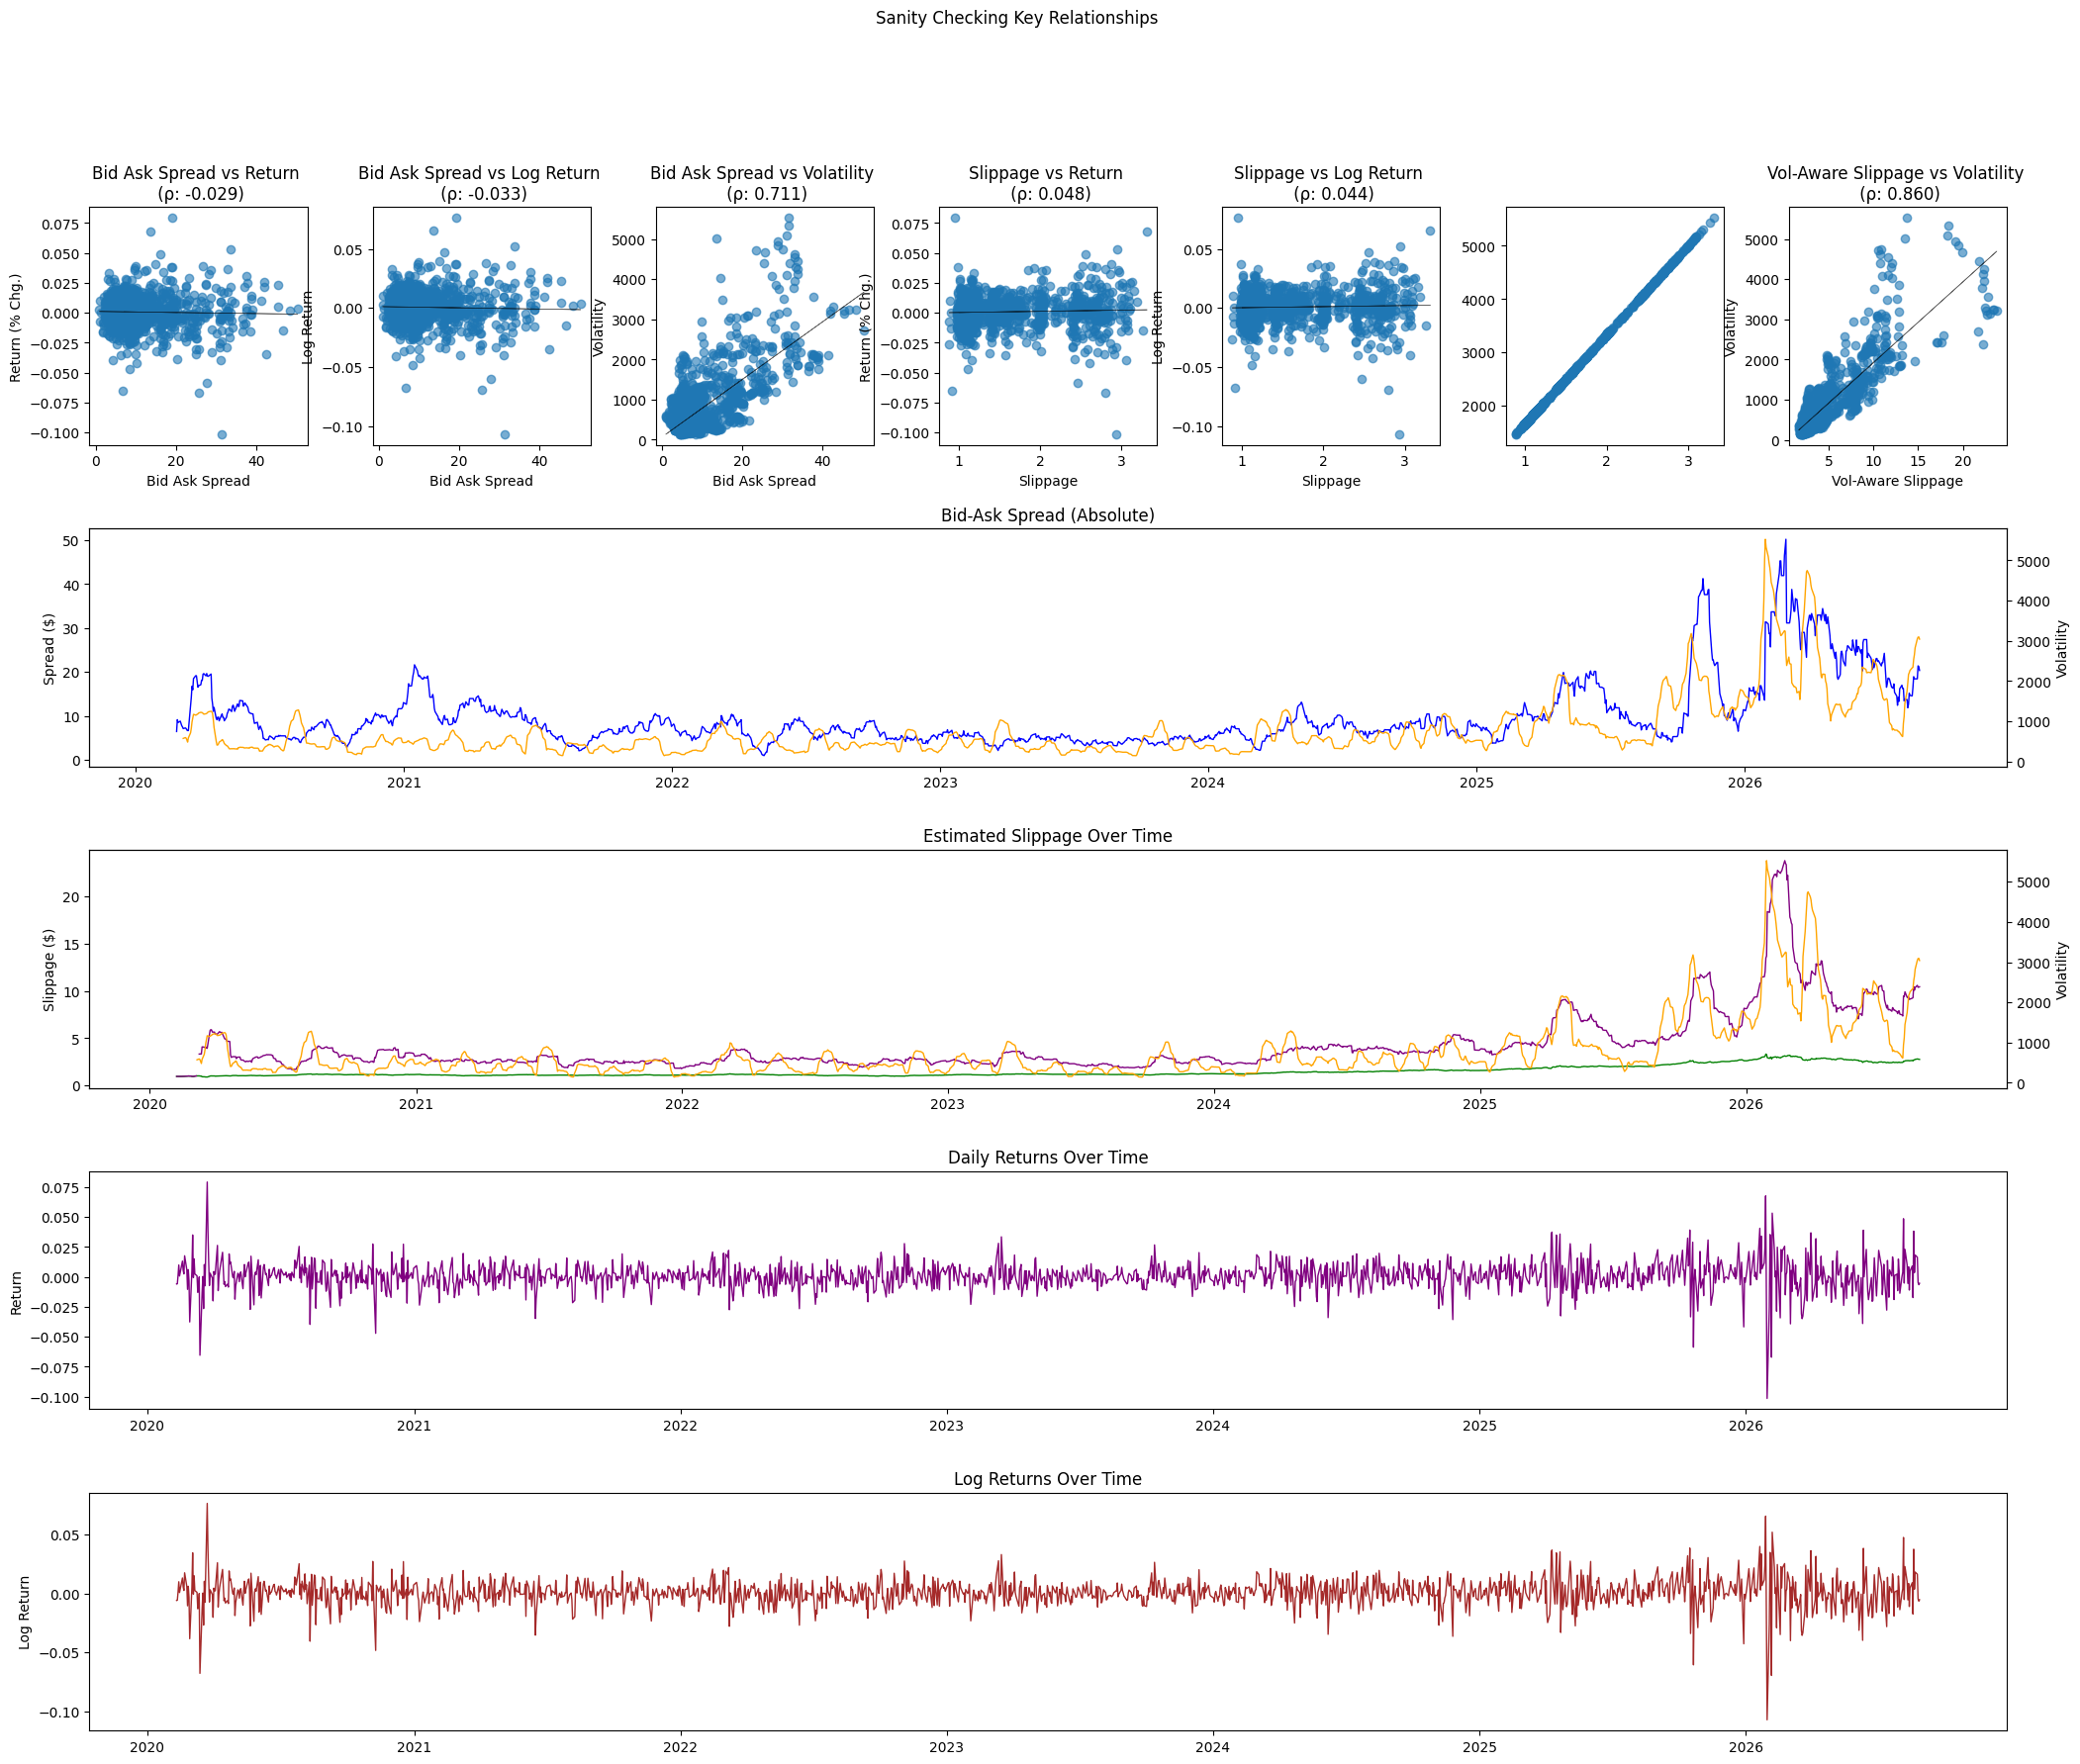

In [45]:
fig = plt.figure(figsize=(25, 20))
gs = GridSpec(5, 7, figure=fig, height_ratios=[1, 1, 1, 1, 1], hspace=0.35, wspace=0.3)

ax_ba_spread = fig.add_subplot(gs[1, :])
ax_slippage = fig.add_subplot(gs[2, :])
ax_ret = fig.add_subplot(gs[3, :])
ax_log_ret = fig.add_subplot(gs[4, :])

ax_ba_ret = fig.add_subplot(gs[0, 0])
ax_ba_log_ret = fig.add_subplot(gs[0, 1])
ax_ba_vol = fig.add_subplot(gs[0, 2])
ax_slip_ret = fig.add_subplot(gs[0,3])
ax_slip_log_ret = fig.add_subplot(gs[0,4])
ax_slip_price = fig.add_subplot(gs[0,5])
ax_vol_slip_vol = fig.add_subplot(gs[0,6])


ax_ba_spread.plot(bid_ask_spread_abs, color='blue', label='Bid-Ask Spread (Abs)', linewidth=1)
ax_ba_spread.set_title('Bid-Ask Spread (Absolute)', fontsize=12)
ax_ba_spread.set_ylabel('Spread ($)', fontsize=10)

ax_ba_spread_twin = ax_ba_spread.twinx()
ax_ba_spread_twin.plot(vol.index, vol.values, color='orange', label='Volatility', linewidth=1)
ax_ba_spread_twin.set_ylabel('Volatility', fontsize=10)

ax_slippage.plot(slippage_series, color='green', label='Estimated Slippage', linewidth=1)
ax_slippage.set_title('Estimated Slippage Over Time', fontsize=12)
ax_slippage.set_ylabel('Slippage ($)', fontsize=10)

ax_slippage.plot(vol_slippage_series, color='purple', label="Vol-Aware Slippage",linewidth=1)

ax_slippage_twin = ax_slippage.twinx()
ax_slippage_twin.plot(vol.index, vol.values, color='orange', label='Volatility', linewidth=1)
ax_slippage_twin.set_ylabel('Volatility', fontsize=10)

ax_ret.plot(ret, color='purple', label='Daily Return', linewidth=1)
ax_ret.set_title('Daily Returns Over Time', fontsize=12)
ax_ret.set_ylabel('Return', fontsize=10)

ax_log_ret.plot(log_ret, color='brown', label='Log Return', linewidth=1)
ax_log_ret.set_title('Log Returns Over Time', fontsize=12)
ax_log_ret.set_ylabel('Log Return', fontsize=10)


if df_corr.empty:
    ax_ba_vol.text(0.5, 0.5, "No overlapping data to compute correlations.", ha='center', va='center')
    ax_ba_ret.axis('off')
else:
    # bid ask spread and return
    ax_ba_ret.scatter(df_corr['bid_ask_spread'], df_corr['ret'], alpha=0.6)
    if len(df_corr) > 1:
        m, b = np.polyfit(df_corr['bid_ask_spread'], df_corr['ret'], 1)
        ax_ba_ret.plot(df_corr['bid_ask_spread'], m * df_corr['bid_ask_spread'] + b, color='black', linewidth=0.5, alpha=0.6)
    ax_ba_ret.set_xlabel('Bid Ask Spread')
    ax_ba_ret.set_ylabel('Return (% Chg.)')
    ax_ba_ret.set_title(f'Bid Ask Spread vs Return \n (ρ: {ba_spread_ret_corr:.3f})')

    # bid ask spread and log return
    ax_ba_log_ret.scatter(df_corr['bid_ask_spread'], df_corr['log_ret'], alpha=0.6)
    if len(df_corr) > 1:
        m, b = np.polyfit(df_corr['bid_ask_spread'], df_corr['log_ret'], 1)
        ax_ba_log_ret.plot(df_corr['bid_ask_spread'], m * df_corr['bid_ask_spread'] + b, color='black', linewidth=0.5, alpha=0.6)
    ax_ba_log_ret.set_xlabel('Bid Ask Spread')
    ax_ba_log_ret.set_ylabel('Log Return')
    ax_ba_log_ret.set_title(f'Bid Ask Spread vs Log Return \n (ρ: {ba_spread_log_ret_corr:.3f})')

    # bid ask spread and volatility
    ax_ba_vol.scatter(df_corr['bid_ask_spread'], df_corr['vol'], alpha=0.6)
    if len(df_corr) > 1:
        m, b = np.polyfit(df_corr['bid_ask_spread'], df_corr['vol'], 1)
        ax_ba_vol.plot(df_corr['bid_ask_spread'], m * df_corr['bid_ask_spread'] + b, color='black', linewidth=0.5, alpha=0.6)
    ax_ba_vol.set_xlabel('Bid Ask Spread')
    ax_ba_vol.set_ylabel('Volatility')
    ax_ba_vol.set_title(f'Bid Ask Spread vs Volatility \n (ρ: {ba_spread_vol_corr:.3f})')

    # slippage and return
    ax_slip_ret.scatter(slippage_series.reindex(df_corr.index), df_corr['ret'], alpha=0.6)
    if len(slippage_series.reindex(df_corr.index).dropna()) > 1:
        m, b = np.polyfit(slippage_series.reindex(df_corr.index).dropna(), df_corr['ret'].loc[slippage_series.reindex(df_corr.index).notna()], 1)
        ax_slip_ret.plot(slippage_series.reindex(df_corr.index).dropna(), m * slippage_series.reindex(df_corr.index).dropna() + b, color='black', linewidth=0.5, alpha=0.6)
    ax_slip_ret.set_xlabel('Slippage')
    ax_slip_ret.set_ylabel('Return (% Chg.)')
    ax_slip_ret.set_title(f'Slippage vs Return \n (ρ: {slip_ret_corr:.3f})')

    # slippage and log return
    ax_slip_log_ret.scatter(slippage_series.reindex(df_corr.index), df_corr['log_ret'], alpha=0.6)
    if len(slippage_series.reindex(df_corr.index).dropna()) > 1:
        m, b = np.polyfit(slippage_series.reindex(df_corr.index).dropna(), df_corr['log_ret'].loc[slippage_series.reindex(df_corr.index).notna()], 1)
        ax_slip_log_ret.plot(slippage_series.reindex(df_corr.index).dropna(), m * slippage_series.reindex(df_corr.index).dropna() + b, color='black', linewidth=0.5, alpha=0.6)
    ax_slip_log_ret.set_xlabel('Slippage')
    ax_slip_log_ret.set_ylabel('Log Return')
    ax_slip_log_ret.set_title(f'Slippage vs Log Return \n (ρ: {slip_log_ret_corr:.3f})')

    # slippage and price
    ax_slip_price.scatter(slippage_series.reindex(df_1['Close'].index), df_1['Close'], alpha = 0.6)

    # slippage and volatility
    ax_vol_slip_vol.scatter(vol_slippage_series.reindex(df_corr.index), df_corr['vol'], alpha=0.6)
    if len(vol_slippage_series.reindex(df_corr.index).dropna()) > 1:
        m, b = np.polyfit(vol_slippage_series.reindex(df_corr.index).dropna(), df_corr['vol'].loc[vol_slippage_series.reindex(df_corr.index).notna()], 1)
        ax_vol_slip_vol.plot(vol_slippage_series.reindex(df_corr.index).dropna(), m * vol_slippage_series.reindex(df_corr.index).dropna() + b, color='black', linewidth=0.5, alpha=0.6)
    ax_vol_slip_vol.set_xlabel('Vol-Aware Slippage')
    ax_vol_slip_vol.set_ylabel('Volatility')
    ax_vol_slip_vol.set_title(f'Vol-Aware Slippage vs Volatility \n (ρ: {vol_slip_vol_corr:.3f})')

    # # volatility and vol-aware slippage
    # ax_vol_slip_vol.scatter(vol.reindex(df_corr.index), vol_slippage_series.reindex(df_corr.index), alpha=0.6)
    # if len(vol.reindex(df_corr.index).dropna()) > 1:
    #     m, b = np.polyfit(vol.reindex(df_corr.index).dropna(), vol_slippage_series.reindex(df_corr.index).loc[vol.reindex(df_corr.index).notna()], 1)
    #     ax_vol_slip_vol.plot(vol.reindex(df_corr.index).dropna(), m * vol.reindex(df_corr.index).dropna() + b, color='black', linewidth=0.5, alpha=0.6)
    # ax_vol_slip_vol.set_xlabel('Volatility')
    # ax_vol_slip_vol.set_ylabel('Vol-Aware Slippage')
    # ax_vol_slip_vol.set_title(f'Volatility vs Vol-Aware Slippage \n (ρ: {vol_slip_vol_corr:.3f})')


#plt.tight_layout()
plt.suptitle("Sanity Checking Key Relationships")
plt.show()


### 10. Optimal entry/exit thresholding w/ stop loss - Zeng & Lee (2014)

In [24]:
# optimal entry/exit thresholds via OU return-per-unit-time


roundtrip_cost = 10   # <-- KEY KNOB: round-trip cost in SPREAD ($/oz) units. Set from your cost model.

# --- 1. Fit OU: dX = mu*(theta - X)dt + sigma dW, via exact AR(1) discretisation (dt = 1 day) ---
def fit_ou(s):
    s = s.dropna(); x0, x1 = s.values[:-1], s.values[1:]
    B, A = np.polyfit(x0, x1, 1)
    mu = -np.log(B); theta = A / (1 - B)
    resid = x1 - (A + B * x0)
    sigma = np.sqrt(resid.var(ddof=2) * 2 * mu / (1 - B**2))
    return mu, theta, sigma

# --- 2. Expected trade length E[T] (dimensionless series, stable recurrence; odd in z) ---
def S(z, nt=200, tol=1e-16):
    term = np.sqrt(2 * np.pi) * z; s = term
    for k in range(1, nt):
        term *= (2*k - 1) * z*z / ((2*k + 1) * (2*k)); s += term
        if abs(term) < tol * abs(s): break
    return s

# --- 3. Optimise a_d for both rules (paper proves exit is 0 or -a_d) ---
def optimise(rule):
    if rule == 'conventional':                        # exit at mean (b_d = 0)
        f = lambda a: -((a - c_d) / ET(a, 0)) if a > c_d else 1e9
    else:                                             # 'new': exit at opposite extreme (b_d = -a_d)
        f = lambda a: -((2*a - c_d) / ET(a, -a)) if 2*a > c_d else 1e9
    return minimize_scalar(f, bounds=(0.05, 6), method='bounded').x# --- 3. Optimise a_d for both rules (paper proves exit is 0 or -a_d) ---
def optimise(rule):
    if rule == 'conventional':                        # exit at mean (b_d = 0)
        f = lambda a: -((a - c_d) / ET(a, 0)) if a > c_d else 1e9
    else:                                             # 'new': exit at opposite extreme (b_d = -a_d)
        f = lambda a: -((2*a - c_d) / ET(a, -a)) if 2*a > c_d else 1e9
    return minimize_scalar(f, bounds=(0.05, 6), method='bounded').x



OU fit: mu=1.0029/day  theta=0.7559  sigma=26.8802
        equilibrium std (z-unit) = 18.9794   half-life = 0.7 days

CONVENTIONAL  entry_z = ±1.29, exit_z = 0        E[T]≈2.2d
NEW (flip)    entry_z = ±0.98, exit_z = ∓0.98  E[T]≈2.9d


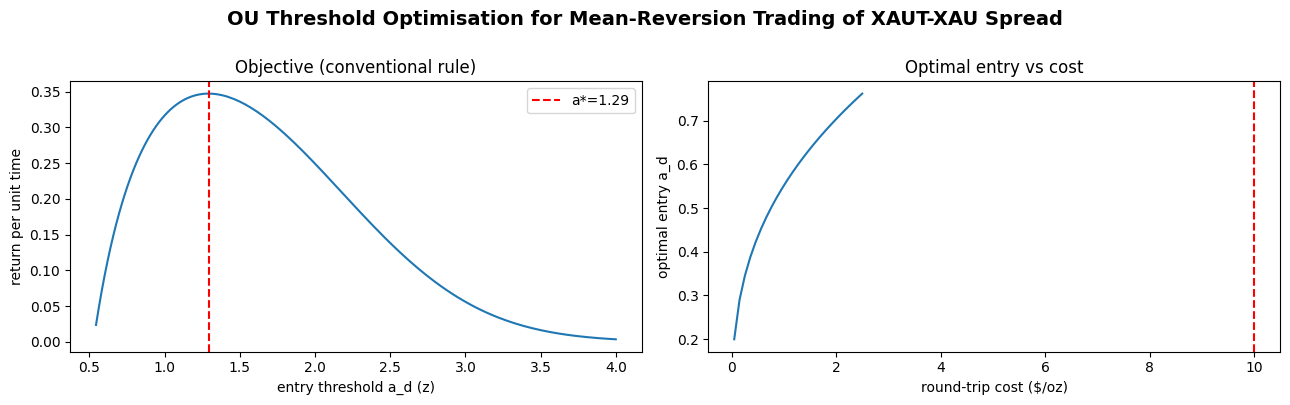

In [25]:
# --- 1. Fit OU: dX = mu*(theta - X)dt + sigma dW, via exact AR(1) discretisation (dt = 1 day) ---

mu, theta, sigma = fit_ou(spread1)
sig_eq   = sigma / np.sqrt(2 * mu)      # OU equilibrium std  -> the "z" unit the thresholds live in
half_life = np.log(2) / mu              # trading days
c_d = roundtrip_cost / sig_eq           # cost in dimensionless units



# --- 2. Expected trade length E[T] (dimensionless series, stable recurrence; odd in z) ---

ET = lambda a_d, b_d: (S(a_d) - S(b_d)) / (2 * mu)   # in days

# --- 3. Optimise a_d for both rules (paper proves exit is 0 or -a_d) ---
a_conv = optimise('conventional')
a_new  = optimise('new')

print(f"OU fit: mu={mu:.4f}/day  theta={theta:.4f}  sigma={sigma:.4f}")
print(f"        equilibrium std (z-unit) = {sig_eq:.4f}   half-life = {half_life:.1f} days\n")
print(f"CONVENTIONAL  entry_z = ±{a_conv:.2f}, exit_z = 0        E[T]≈{ET(a_conv,0):.1f}d")
print(f"NEW (flip)    entry_z = ±{a_new:.2f}, exit_z = ∓{a_new:.2f}  E[T]≈{ET(a_new,-a_new):.1f}d")

# --- 4. Standardise the spread in OU units so the thresholds apply exactly ---
df['Z_OU'] = (spread1.reindex(df.index) - theta) / sig_eq   # use this as 'Z-Score' with entry_z=a_conv, exit_z=0

# --- 5. Sensitivity: optimal entry vs cost (the one input you don't know precisely) ---
costs = np.linspace(0.05, 2.5, 25)
a_by_cost = []
for cc in costs:
    cd = cc / sig_eq
    a_by_cost.append(minimize_scalar(
        lambda a: -((a - cd)/ET(a,0)) if a > cd else 1e9, bounds=(0.05,6), method='bounded').x)

fig, ax = plt.subplots(1, 2, figsize=(13,4))
grid = np.linspace(0.2, 4, 200)
ax[0].plot(grid, [ -(-((a-c_d)/ET(a,0))) if a>c_d else np.nan for a in grid])
ax[0].axvline(a_conv, color='r', ls='--', label=f'a*={a_conv:.2f}')
ax[0].set_xlabel('entry threshold a_d (z)'); ax[0].set_ylabel('return per unit time'); ax[0].legend()
ax[0].set_title('Objective (conventional rule)')
ax[1].plot(costs, a_by_cost); ax[1].axvline(roundtrip_cost, color='r', ls='--')
ax[1].set_xlabel('round-trip cost ($/oz)'); ax[1].set_ylabel('optimal entry a_d')
ax[1].set_title('Optimal entry vs cost')
plt.suptitle('OU Threshold Optimisation for Mean-Reversion Trading of XAUT-XAU Spread', fontsize=14, fontweight='bold', y=1)
plt.tight_layout()
plt.show()


OU fit: mu=0.9178/day  theta=-1.3405  sigma=26.4607
        equilibrium std (z-unit) = 19.5305   half-life = 0.8 days

CONVENTIONAL  entry_z = ±1.28, exit_z = 0        E[T]≈2.4d
NEW (flip)    entry_z = ±0.97, exit_z = ∓0.97  E[T]≈3.1d


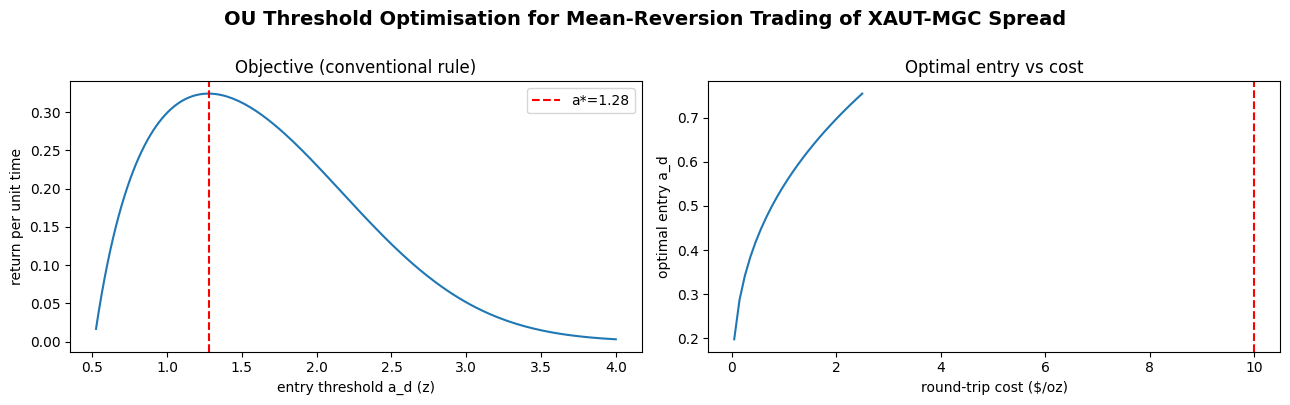

In [26]:
# --- 1. Fit OU: dX = mu*(theta - X)dt + sigma dW, via exact AR(1) discretisation (dt = 1 day) ---

mu, theta, sigma = fit_ou(spread2)
sig_eq   = sigma / np.sqrt(2 * mu)      # OU equilibrium std  -> the "z" unit the thresholds live in
half_life = np.log(2) / mu              # trading days
c_d = roundtrip_cost / sig_eq           # cost in dimensionless units



# --- 2. Expected trade length E[T] (dimensionless series, stable recurrence; odd in z) ---

ET = lambda a_d, b_d: (S(a_d) - S(b_d)) / (2 * mu)   # in days

# --- 3. Optimise a_d for both rules (paper proves exit is 0 or -a_d) ---
a_conv = optimise('conventional')
a_new  = optimise('new')

print(f"OU fit: mu={mu:.4f}/day  theta={theta:.4f}  sigma={sigma:.4f}")
print(f"        equilibrium std (z-unit) = {sig_eq:.4f}   half-life = {half_life:.1f} days\n")
print(f"CONVENTIONAL  entry_z = ±{a_conv:.2f}, exit_z = 0        E[T]≈{ET(a_conv,0):.1f}d")
print(f"NEW (flip)    entry_z = ±{a_new:.2f}, exit_z = ∓{a_new:.2f}  E[T]≈{ET(a_new,-a_new):.1f}d")

# --- 4. Standardise the spread in OU units so the thresholds apply exactly ---
df['Z_OU'] = (spread2.reindex(df.index) - theta) / sig_eq   # use this as 'Z-Score' with entry_z=a_conv, exit_z=0

# --- 5. Sensitivity: optimal entry vs cost (the one input you don't know precisely) ---
costs = np.linspace(0.05, 2.5, 25)
a_by_cost = []
for cc in costs:
    cd = cc / sig_eq
    a_by_cost.append(minimize_scalar(
        lambda a: -((a - cd)/ET(a,0)) if a > cd else 1e9, bounds=(0.05,6), method='bounded').x)

fig, ax = plt.subplots(1, 2, figsize=(13,4))
grid = np.linspace(0.2, 4, 200)
ax[0].plot(grid, [ -(-((a-c_d)/ET(a,0))) if a>c_d else np.nan for a in grid])
ax[0].axvline(a_conv, color='r', ls='--', label=f'a*={a_conv:.2f}')
ax[0].set_xlabel('entry threshold a_d (z)'); ax[0].set_ylabel('return per unit time'); ax[0].legend()
ax[0].set_title('Objective (conventional rule)')
ax[1].plot(costs, a_by_cost); ax[1].axvline(roundtrip_cost, color='r', ls='--')
ax[1].set_xlabel('round-trip cost ($/oz)'); ax[1].set_ylabel('optimal entry a_d')
ax[1].set_title('Optimal entry vs cost')
plt.suptitle('OU Threshold Optimisation for Mean-Reversion Trading of XAUT-MGC Spread', fontsize=14, fontweight='bold', y=1)
plt.tight_layout() 
plt.show()

C:\Users\ayode\AppData\Local\Temp\ipykernel_4552\3121097288.py:32: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im  = ax1.pcolormesh(a_grid, cost_grid, Z, cmap='coolwarm', shading='auto')


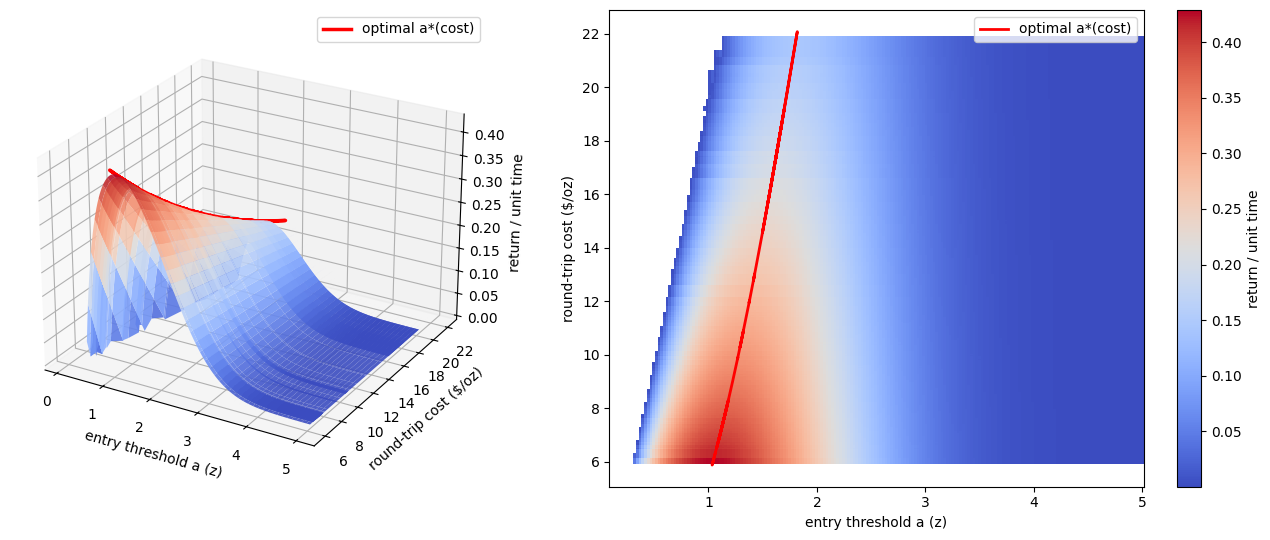

In [27]:
from mpl_toolkits.mplot3d import Axes3D  # noqa

# ---- cost axis: 40bps of price, so $/oz varies with the gold level ----
bps        = 40
price_grid = data_weekdays['XAUT-USD']['Close']# * np.linspace(0.8, 1.2, 60)  # realistic range
cost_grid  = bps/1e4 * price_grid             # round-trip cost $/oz
a_grid     = np.linspace(0.1, 5, 200)       # entry threshold (z-units)

# ---- surface: return per unit time (z/day) ----
A, C = np.meshgrid(a_grid, cost_grid)         # (n_cost, n_a)
CD   = C / sig_eq                             # cost -> z-units
ET0  = np.array([ET(a, 0) for a in a_grid])   # ET(a,0) depends only on a
Z    = (A - CD) / ET0[None, :]
Z[A <= CD] = np.nan                           # unprofitable region

# ---- optimal ridge a*(cost) ----
a_star, z_star = [], []
for cost in cost_grid:
    cd = cost / sig_eq
    r  = minimize_scalar(lambda a: -((a-cd)/ET(a,0)) if a>cd else 1e9,
                         bounds=(0.05, 6), method='bounded')
    a_star.append(r.x); z_star.append(-r.fun)

fig = plt.figure(figsize=(14,5.5))
ax0 = fig.add_subplot(1,2,1, projection='3d')
ax0.plot_surface(A, C, Z, cmap='coolwarm', alpha=0.9, linewidth=0)
ax0.plot(a_star, cost_grid, z_star, 'r-', lw=2.5, label='optimal a*(cost)')
ax0.set_xlabel('entry threshold a (z)'); ax0.set_ylabel('round-trip cost ($/oz)')
ax0.set_zlabel('return / unit time'); ax0.view_init(25, -60); ax0.legend()

ax1 = fig.add_subplot(1,2,2)
im  = ax1.pcolormesh(a_grid, cost_grid, Z, cmap='coolwarm', shading='auto')
ax1.plot(a_star, cost_grid, 'r-', lw=2, label='optimal a*(cost)')
ax1.set_xlabel('entry threshold a (z)'); ax1.set_ylabel('round-trip cost ($/oz)')
fig.colorbar(im, ax=ax1, label='return / unit time'); ax1.legend()
plt.tight_layout(); plt.show()

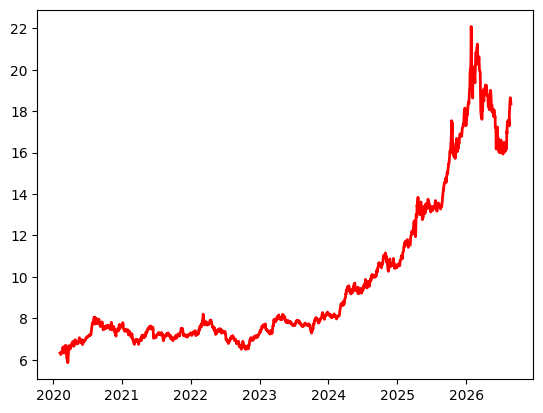

In [28]:
plt.plot(cost_grid.index, cost_grid.values, 'r-', lw=2)

before moving on to backtesting,   naive slippage model is based on contributions from order volume, asset volatility,  bid ask spread and minimum slippage component.
order volume's contribution is based on the ratio  of order size to average daily volume (ADV) (participation rate),
can't find data on average daily volume growth/changes  over train and test periods,
to account for this, I will use an exponential growth curve to meet the current average daily volume - otherwise it would simply be a rollinng mean of volume * close price

In [29]:
# average daily volume assumtion 
adv = 203_561_794 # $203,561,794 in the last 24 hours as at 24/08/2026

In [30]:
model = SlippageModel()

### 11. Signal Generation - 

In [31]:
# Signal Generation Parameters
window = 20
entry_threshold = 2
exit_threshold = 0

beta_adj = False
asset_A = 'XAUT-USD' # xaut usd
asset_B = 'GC=F' # gold futures



# Time Considerations
test_start = '2024-01-01'

# Slippage & Spread Parameters
slippage_const = 0.0005 # 5 bps slippage constant
ba_spread_target = 30 # target spread in pips

# Boolean Flags
debug_mode = False
use_cse_spread = True
use_ou_thresholds = True
use_slippage_model = True

In [32]:
# Data Prep
# Use the full aligned history for the rolling z-score.
# Then slice to the analysis/test window after the z-score is built.

analysis_start = "2024-01-01"

aligned = {
    asset: data_weekdays[asset].copy()
    for asset in (asset_A, asset_B)
}

# keep only common dates across the two assets
common_idx = aligned[asset_A].index.intersection(aligned[asset_B].index)
for asset in (asset_A, asset_B):
    aligned[asset] = aligned[asset].loc[common_idx]

spread, beta = compute_spread(
    aligned,
    asset_A,
    asset_B,
    beta=beta_adj,
    debug=debug_mode
)

spread = spread.dropna()

# rolling z-score with warm-up allowed
rolling_mean = spread.rolling(window=window, min_periods=1).mean()
rolling_std = spread.rolling(window=window, min_periods=1).std(ddof=0)
zscore = (spread - rolling_mean) / rolling_std
zscore = zscore.replace([np.inf, -np.inf], np.nan)

df = pd.DataFrame({
    asset_A: aligned[asset_A].loc[spread.index, 'Close'],
    asset_B: aligned[asset_B].loc[spread.index, 'Close'],
    'Spread': spread,
    'Z-Score': zscore
}).loc[analysis_start:]

In [33]:

# Signal Generation — symmetric exit band (Zeng-Lee b_d), + stop-loss + time-stop
# exit_z is signed and equals Zeng & Lee's b_d exactly (entry_z == their a_d):
#   exit_z = 0        -> close at the mean            (conventional optimum)
#   0 < exit_z < entry_z -> close before the mean     (partial revert)
#   exit_z = -entry_z -> close at the opposite extreme (new/"always-in" optimum)
entry_z       = entry_threshold   # a_d
exit_z        = exit_threshold    # b_d  (set to 0 for classic exit-at-mean)
stop_z        = None              # e.g. 4.0 -> hard stop if spread diverges further
max_holding   = None              # e.g. 15 -> time-stop in trading days

def generate_positions(z, entry_z, exit_z, stop_z=None, max_holding=None):
    pos = np.zeros(len(z))
    state, entry_i = 0, None
    for i in range(len(z)):
        zi = z[i]
        if np.isnan(zi):
            pos[i] = state
            continue
        if state == 0:
            if   zi < -entry_z: state, entry_i = 1, i      # long the spread
            elif zi >  entry_z: state, entry_i = -1, i     # short the spread
        elif state == 1:       # long: opened at z < -entry_z, close at z >= -exit_z
            held = i - entry_i
            if (zi >= -exit_z) \
               or (stop_z is not None and zi <= -stop_z) \
               or (max_holding is not None and held >= max_holding):
                state, entry_i = 0, None
        elif state == -1:      # short: opened at z > entry_z, close at z <= exit_z
            held = i - entry_i
            if (zi <= exit_z) \
               or (stop_z is not None and zi >= stop_z) \
               or (max_holding is not None and held >= max_holding):
                state, entry_i = 0, None
        pos[i] = state
    return pos

df['Position'] = generate_positions(df['Z-Score'].values, entry_z, exit_z, stop_z, max_holding)

# ---- performance block (unchanged) ----
df['Asset_A_Return'] = df[asset_A].pct_change()
df['Asset_B_Return'] = df[asset_B].pct_change()
df['Beta'] = beta.reindex(df.index).ffill()
spread_return = df['Asset_A_Return'] - df['Beta'] * df['Asset_B_Return']
df['Strategy_Return'] = df['Position'].shift(1).fillna(0) * spread_return
df['Strategy_Return'] = df['Strategy_Return'] - slippage_const * df['Position'].diff().abs().fillna(0)
df['Strategy_Return'] = df['Strategy_Return'].fillna(0)



# Performance Evaluation
# calculate returns
df['Asset_A_Return'] = df[asset_A].pct_change()
df['Asset_B_Return'] = df[asset_B].pct_change()

# align beta series to df index
df['Beta'] = beta.reindex(df.index).ffill()

# spread return, then apply previous day's position to avoid lookahead bias
spread_return = df['Asset_A_Return'] - df['Beta'] * df['Asset_B_Return']
df['Strategy_Return'] = df['Position'].shift(1).fillna(0) * spread_return

# apply fees to strategy returns
df['Strategy_Return'] = df['Strategy_Return'] - slippage_const * df['Position'].diff().abs().fillna(0)

# optional cleanup for first row
df['Strategy_Return'] = df['Strategy_Return'].fillna(0)

**********redo/recheck everything from here onwards****************

In [34]:
# 2 Leg PNL Calculations with individual trade tracking
# Replacement cell:
# - Buy at ask, sell at bid using Corwin-Schultz full spread / 2
# - Adds naive market-impact slippage on top of bid/ask execution
# - Sizes token leg from whole futures contracts
# - Keeps original output columns used by plotting:
#   trades_df, entry_date, exit_date, direction, entry_zscore, exit_zscore,
#   entry_price_a/b, exit_price_a/b, entry_slippage_a/b, exit_slippage_a/b,
#   beta, holding_period, pnl_a, pnl_b, net_pnl, total_slippage,
#   total_fees, total_costs, net_pnl_after_costs, return_pct

import numpy as np
import pandas as pd

# -----------------------------
# Config
# -----------------------------     

slippage_model = SlippageModel(min_slippage_bps=1.0)  # 1 bps minimum

# Use MGC-style sizing by default.
# MGC = 10 oz. GC = 100 oz.
futures_contract_size_oz = 10
target_futures_contracts = 3

# Token fee: Binance retail taker-ish assumption.
# This is applied only to token notional, not futures notional.
token_fee_rate = 0.001

# Futures all-in fee estimate per contract per side.
# Tune this to your broker/exchange reality.
futures_fee_per_contract = 1.50

# Fallback daily dollar volume assumptions if real volume cols are missing.
fallback_token_dollar_volume = 50_000_000
fallback_futures_dollar_volume = 500_000_000

# Fallback full bid/ask spread in bps if CS spread is missing.
fallback_token_spread_bps = 1.0
fallback_futures_spread_bps = 1.0


# -----------------------------
# Corwin-Schultz spread series
# -----------------------------
# Assumes cs_spread_estimator() already exists and data_weekdays[asset] has High/Low columns.
# Returns full bid/ask spread in absolute dollars, lagged by 1 day inside the function.

# try:
#     spread_a_series = cs_spread_estimator(
#         data_weekdays[asset_A],
#         abs=True,
#         bps=False,
#         pips=False
#     ).reindex(df.index).ffill()
# except Exception:
#     spread_a_series = pd.Series(index=df.index, data=np.nan)

# try:
#     spread_b_series = cs_spread_estimator(
#         data_weekdays[asset_B],
#         abs=True,
#         bps=False,
#         pips=False
#     ).reindex(df.index).ffill()
# except Exception:
#     spread_b_series = pd.Series(index=df.index, data=np.nan)

# CS from daily bars overestimates the true quote by ~100x, so use it only for
# its shape and anchor the level to a realistic per-leg target (full bid/ask, bps).
target_token_spread_bps   = 10.0   # XAUT/PAXG on a major venue: ~5-20 bps
target_futures_spread_bps = 1.0    # GC/MGC: ~1 tick, sub-bp to ~1 bp

def scaled_dollar_spread(asset, target_bps):
    cs = corwin_schultz_spread(data_weekdays[asset], absolute=True, agg="rolling", window=window).reindex(df.index).ffill()
    if cs.notna().sum() == 0 or cs.mean() == 0:
        cs = pd.Series(target_bps / 10000, index=df.index)
    else:
        cs = cs / cs.mean() * (target_bps / 10000)   # rescale level, keep dynamics
    return cs * df[asset]                              # -> dollars per oz

spread_a_series = scaled_dollar_spread(asset_A, target_token_spread_bps)
spread_b_series = scaled_dollar_spread(asset_B, target_futures_spread_bps)

# -----------------------------
# Helpers
# -----------------------------

def get_cs_spread_dollars(date, spread_series, mid_price, fallback_bps):
    """
    Full bid/ask spread in dollars.
    Corwin-Schultz spread is expected to be absolute dollar spread.
    """
    spread_val = np.nan

    if date in spread_series.index:
        spread_val = spread_series.loc[date]

    if pd.isna(spread_val) or spread_val < 0:
        spread_val = mid_price * fallback_bps / 10000

    return float(spread_val)


def get_daily_dollar_volume(date, asset, price, kind):
    """
    Attempts to use real volume from data_weekdays or df.

    Token volume convention:
      volume units * price = dollar volume

    Futures volume convention:
      contract volume * contract_size_oz * price = dollar volume

    Falls back if no usable volume column exists.
    """

    volume_candidates = ["Volume", "volume", "Vol", "vol"]

    # First try data_weekdays[asset]
    try:
        asset_df = data_weekdays[asset]
        for col in volume_candidates:
            if col in asset_df.columns and date in asset_df.index:
                vol = asset_df.loc[date, col]
                if pd.notna(vol) and vol > 0:
                    if kind == "token":
                        return float(vol * price)
                    if kind == "futures":
                        return float(vol * futures_contract_size_oz * price)
    except Exception:
        pass

    # Then try df columns like "PAXG-USD_Volume", "GC=F_Volume", etc.
    df_candidates = [
        f"{asset}_Volume",
        f"{asset}_volume",
        f"{asset}_Vol",
        f"{asset}_vol",
    ]

    for col in df_candidates:
        if col in df.columns and date in df.index:
            vol = df.loc[date, col]
            if pd.notna(vol) and vol > 0:
                if kind == "token":
                    return float(vol * price)
                if kind == "futures":
                    return float(vol * futures_contract_size_oz * price)

    if kind == "token":
        return fallback_token_dollar_volume

    return fallback_futures_dollar_volume


def get_volatility(asset, i):
    """
    Uses your SlippageModel volatility calc if available.
    Falls back to rolling return volatility.
    """
    try:
        return slippage_model.calculate_volatility(df[asset].iloc[:i + 1])
    except Exception:
        returns = df[asset].pct_change().iloc[:i + 1].dropna()
        if len(returns) == 0:
            return 0.0
        return float(returns.tail(20).std())


def estimate_impact(price, notional, dollar_volume, volatility=None, bid_ask_spread=None):
    """
    Market-impact component in dollars per oz/token.

    Your SlippageModel appears to expect order_size in oz/token units,
    so this converts notional dollars into units first.
    """
    if price <= 0:
        return 0.0

    order_size_units = abs(notional) / price

    try:
        impact = slippage_model.estimate_slippage(
            price,
            order_size_units,
            dollar_volume,
            volatility,
            bid_ask_spread
        )
    except TypeError:
        try:
            impact = slippage_model.estimate_slippage(
                price,
                order_size_units,
                dollar_volume
            )
        except Exception:
            impact = price * 0.0001
    except Exception:
        impact = price * 0.0001

    if pd.isna(impact) or impact < 0:
        impact = price * 0.0001

    return float(impact)


def execute_price(mid_price, side, spread_dollars, impact_dollars):
    """
    Buy at ask plus impact.
    Sell at bid minus impact.
    """
    half_spread = spread_dollars / 2.0

    if side == "buy":
        return mid_price + half_spread + impact_dollars

    if side == "sell":
        return mid_price - half_spread - impact_dollars

    raise ValueError("side must be 'buy' or 'sell'")


def token_fee(notional):
    return token_fee_rate * abs(notional)


def futures_fee(num_contracts):
    return futures_fee_per_contract * abs(num_contracts)


# -----------------------------
# Trade tracking
# -----------------------------

trades = []
current_trade = None

# Keep these variables for compatibility/debugging
position_changes = df["Position"].diff().fillna(0)
entry_points = position_changes != 0
exit_points = (df["Position"] == 0) & (df["Position"].shift(1) != 0)


# -----------------------------
# Process each trade
# -----------------------------

for i in range(1, len(df)):
    current_pos = df["Position"].iloc[i]
    prev_pos = df["Position"].iloc[i - 1]
    date = df.index[i]

    # -----------------------------
    # Trade entry
    # -----------------------------
    if prev_pos == 0 and current_pos != 0:
        asset_a_price = df[asset_A].iloc[i]
        asset_b_price = df[asset_B].iloc[i]
        beta_value = df["Beta"].iloc[i]

        # Whole futures contracts only.
        futures_contracts = target_futures_contracts
        futures_oz = futures_contracts * futures_contract_size_oz

        # Match token ounces to futures exposure.
        # If beta is not meant to be hedge ratio in oz terms, set token_oz = futures_oz.
        b = abs(beta_value)
        token_oz = futures_oz / b if b > 0.2 else futures_oz   # neutral vs A - beta*B
        #token_oz = futures_oz * abs(beta_value)

        token_notional = token_oz * asset_a_price
        futures_notional = futures_oz * asset_b_price

        vol_a = get_daily_dollar_volume(date, asset_A, asset_a_price, kind="token")
        vol_b = get_daily_dollar_volume(date, asset_B, asset_b_price, kind="futures")

        spread_a = get_cs_spread_dollars(
            date,
            spread_a_series,
            asset_a_price,
            fallback_token_spread_bps
        )
        spread_b = get_cs_spread_dollars(
            date,
            spread_b_series,
            asset_b_price,
            fallback_futures_spread_bps
        )

        volatility_a = get_volatility(asset_A, i)
        volatility_b = get_volatility(asset_B, i)

        impact_a = estimate_impact(
            price=asset_a_price,
            notional=token_notional,
            dollar_volume=vol_a,
            volatility=None,#volatility_a,
            bid_ask_spread=None,#spread_a
        )
        impact_b = estimate_impact(
            price=asset_b_price,
            notional=futures_notional,
            dollar_volume=vol_b,
            volatility=None,#volatility_b,
            bid_ask_spread=None,#spread_b
        )

        current_trade = {
            "entry_date": date,
            "entry_zscore": df["Z-Score"].iloc[i],
            "direction": "long" if current_pos == 1 else "short",
            "position_size": 1.0,

            "beta": beta_value,

            # Extra diagnostics, should not break old plots
            "token_oz": token_oz,
            "futures_contracts": futures_contracts,
            "futures_oz": futures_oz,
            "entry_mid_a": asset_a_price,
            "entry_mid_b": asset_b_price,
            "entry_spread_a": spread_a,
            "entry_spread_b": spread_b,
            "entry_impact_a": impact_a,
            "entry_impact_b": impact_b,
            "entry_token_notional": token_notional,
            "entry_futures_notional": futures_notional,
            "entry_volume_a": vol_a,
            "entry_volume_b": vol_b,
        }

        if current_pos == 1:
            # Long spread: Buy A, Sell B
            current_trade["entry_side_a"] = "buy"
            current_trade["entry_side_b"] = "sell"
            current_trade["entry_price_a"] = execute_price(asset_a_price, "buy", spread_a, impact_a)
            current_trade["entry_price_b"] = execute_price(asset_b_price, "sell", spread_b, impact_b)
        else:
            # Short spread: Sell A, Buy B
            current_trade["entry_side_a"] = "sell"
            current_trade["entry_side_b"] = "buy"
            current_trade["entry_price_a"] = execute_price(asset_a_price, "sell", spread_a, impact_a)
            current_trade["entry_price_b"] = execute_price(asset_b_price, "buy", spread_b, impact_b)

        # Keep old field names.
        # These are dollar execution cost per unit from mid, including half-spread + impact.
        current_trade["entry_slippage_a"] = abs(current_trade["entry_price_a"] - asset_a_price)
        current_trade["entry_slippage_b"] = abs(current_trade["entry_price_b"] - asset_b_price)

        # Extra diagnostics in dollars.
        current_trade["entry_exec_cost_a"] = current_trade["entry_slippage_a"] * token_oz
        current_trade["entry_exec_cost_b"] = current_trade["entry_slippage_b"] * futures_oz

        current_trade["entry_fees"] = (
            token_fee(current_trade["entry_price_a"] * token_oz)
            + futures_fee(futures_contracts)
        )

    # -----------------------------
    # Trade exit
    # -----------------------------
    elif prev_pos != 0 and current_pos == 0 and current_trade is not None:
        asset_a_price = df[asset_A].iloc[i]
        asset_b_price = df[asset_B].iloc[i]
        beta_value = df["Beta"].iloc[i]

        token_oz = current_trade["token_oz"]
        futures_contracts = current_trade["futures_contracts"]
        futures_oz = current_trade["futures_oz"]

        token_notional = token_oz * asset_a_price
        futures_notional = futures_oz * asset_b_price

        vol_a = get_daily_dollar_volume(date, asset_A, asset_a_price, kind="token")
        vol_b = get_daily_dollar_volume(date, asset_B, asset_b_price, kind="futures")

        spread_a = get_cs_spread_dollars(
            date,
            spread_a_series,
            asset_a_price,
            fallback_token_spread_bps
        )
        spread_b = get_cs_spread_dollars(
            date,
            spread_b_series,
            asset_b_price,
            fallback_futures_spread_bps
        )

        volatility_a = get_volatility(asset_A, i)
        volatility_b = get_volatility(asset_B, i)

        impact_a = estimate_impact(
            price=asset_a_price,
            notional=token_notional,
            dollar_volume=vol_a,
            volatility=None,#volatility_a, - using none till i can find a model that doesnt give me 9% costs for slippage
            bid_ask_spread=None,#spread_a
        )
        impact_b = estimate_impact(
            price=asset_b_price,
            notional=futures_notional,
            dollar_volume=vol_b,
            volatility=None,#volatility_b,
            bid_ask_spread=None,#spread_b
        )

        current_trade["exit_date"] = date
        current_trade["exit_zscore"] = df["Z-Score"].iloc[i]

        # Extra diagnostics
        current_trade["exit_mid_a"] = asset_a_price
        current_trade["exit_mid_b"] = asset_b_price
        current_trade["exit_spread_a"] = spread_a
        current_trade["exit_spread_b"] = spread_b
        current_trade["exit_impact_a"] = impact_a
        current_trade["exit_impact_b"] = impact_b
        current_trade["exit_token_notional"] = token_notional
        current_trade["exit_futures_notional"] = futures_notional
        current_trade["exit_volume_a"] = vol_a
        current_trade["exit_volume_b"] = vol_b
        current_trade["exit_beta"] = beta_value

        if current_trade["direction"] == "long":
            # Exit long spread: Sell A, Buy B
            current_trade["exit_side_a"] = "sell"
            current_trade["exit_side_b"] = "buy"
            current_trade["exit_price_a"] = execute_price(asset_a_price, "sell", spread_a, impact_a)
            current_trade["exit_price_b"] = execute_price(asset_b_price, "buy", spread_b, impact_b)

            pnl_a = (current_trade["exit_price_a"] - current_trade["entry_price_a"]) * token_oz
            pnl_b = (current_trade["entry_price_b"] - current_trade["exit_price_b"]) * futures_oz

        else:
            # Exit short spread: Buy A, Sell B
            current_trade["exit_side_a"] = "buy"
            current_trade["exit_side_b"] = "sell"
            current_trade["exit_price_a"] = execute_price(asset_a_price, "buy", spread_a, impact_a)
            current_trade["exit_price_b"] = execute_price(asset_b_price, "sell", spread_b, impact_b)

            pnl_a = (current_trade["entry_price_a"] - current_trade["exit_price_a"]) * token_oz
            pnl_b = (current_trade["exit_price_b"] - current_trade["entry_price_b"]) * futures_oz

        # Keep old field names.
        # These are dollar execution cost per unit from mid, including half-spread + impact.
        current_trade["exit_slippage_a"] = abs(current_trade["exit_price_a"] - asset_a_price)
        current_trade["exit_slippage_b"] = abs(current_trade["exit_price_b"] - asset_b_price)

        # Extra diagnostics in dollars.
        current_trade["exit_exec_cost_a"] = current_trade["exit_slippage_a"] * token_oz
        current_trade["exit_exec_cost_b"] = current_trade["exit_slippage_b"] * futures_oz

        # Calculate holding period
        current_trade["holding_period"] = (
            current_trade["exit_date"] - current_trade["entry_date"]
        ).days

        # Calculate PnL for each leg
        current_trade["pnl_a"] = pnl_a
        current_trade["pnl_b"] = pnl_b

        # Keep old name, but now this is dollar PnL after embedded execution pricing.
        current_trade["net_pnl"] = pnl_a + pnl_b

        # Total slippage is now dollar execution cost, not per-unit sum.
        # Keeps same column name for plotting.
        total_slippage = (
            current_trade["entry_exec_cost_a"]
            + current_trade["entry_exec_cost_b"]
            + current_trade["exit_exec_cost_a"]
            + current_trade["exit_exec_cost_b"]
        )
        current_trade["total_slippage"] = total_slippage

        # Fees
        current_trade["exit_fees"] = (
            token_fee(current_trade["exit_price_a"] * token_oz)
            + futures_fee(futures_contracts)
        )

        total_fees = current_trade["entry_fees"] + current_trade["exit_fees"]
        current_trade["total_fees"] = total_fees

        # IMPORTANT:
        # Do not subtract total_slippage again.
        # Slippage/spread is already embedded in entry/exit prices.
        # But keep total_costs column for old plots.
        current_trade["total_costs"] = total_fees

        # Net PnL after costs
        current_trade["net_pnl_after_costs"] = current_trade["net_pnl"] - current_trade["total_costs"]

        # Return calculations
        # Use token capital as the capital base; old model used synthetic price sum.
        entry_value = abs(current_trade["entry_token_notional"])
        current_trade["entry_value"] = entry_value

        if entry_value != 0:
            current_trade["return_pct"] = current_trade["net_pnl_after_costs"] / entry_value * 100
        else:
            current_trade["return_pct"] = np.nan

        # More diagnostics
        current_trade["total_execution_cost"] = total_slippage
        current_trade["execution_cost_bps"] = (
            total_slippage / entry_value * 10000 if entry_value != 0 else np.nan
        )
        current_trade["fees_bps"] = (
            total_fees / entry_value * 10000 if entry_value != 0 else np.nan
        )

        trades.append(current_trade.copy())
        current_trade = None


# Convert to DataFrame
trades_df = pd.DataFrame(trades)

if len(trades_df) > 0:
    print(f"Total Trades: {len(trades_df)}")
    print(f"Winning Trades: {len(trades_df[trades_df['net_pnl_after_costs'] > 0])}")
    print(f"Losing Trades: {len(trades_df[trades_df['net_pnl_after_costs'] < 0])}")
    print(f"Win Rate: {len(trades_df[trades_df['net_pnl_after_costs'] > 0]) / len(trades_df) * 100:.1f}%")
    print(f"Average Return per Trade: {trades_df['return_pct'].mean():.4f}%")
    print(f"Best Trade: {trades_df['return_pct'].max():.4f}%")
    print(f"Worst Trade: {trades_df['return_pct'].min():.4f}%")
    print(f"Average Holding Period: {trades_df['holding_period'].mean():.1f} days")
    print(f"Total Slippage per Trade (avg): ${trades_df['total_slippage'].mean():.4f}")
    print(f"Total Fees per Trade (avg): ${trades_df['total_fees'].mean():.4f}")

    # Extra sanity checks
    print(f"Avg Token Notional: ${trades_df['entry_token_notional'].mean():,.2f}")
    print(f"Avg Futures Notional: ${trades_df['entry_futures_notional'].mean():,.2f}")
    print(f"Avg Execution Cost: {trades_df['execution_cost_bps'].mean():.2f} bps")
    print(f"Avg Fees: {trades_df['fees_bps'].mean():.2f} bps")
else:
    print("No trades executed")

Total Trades: 39
Winning Trades: 33
Losing Trades: 6
Win Rate: 84.6%
Average Return per Trade: 0.8720%
Best Trade: 4.1497%
Worst Trade: -0.6300%
Average Holding Period: 4.7 days
Total Slippage per Trade (avg): $360.9952
Total Fees per Trade (avg): $209.9898
Avg Token Notional: $100,425.26
Avg Futures Notional: $100,534.31
Avg Execution Cost: 34.55 bps
Avg Fees: 20.99 bps


In [35]:
# Create cumulative performance series for plotting
if len(trades_df) > 0:
    # Create a daily performance series
    daily_returns = pd.Series(index=df.index, data=0.0, name='daily_strategy_return')
    cumulative_strategy_pnl = pd.Series(index=df.index, data=0.0, name='cumulative_strategy_pnl')
    
    running_pnl = 0
    for _, trade in trades_df.iterrows():
        # Add the trade return on the exit date
        if trade['exit_date'] in daily_returns.index:
            daily_returns.loc[trade['exit_date']] += trade['return_pct'] / 100
            running_pnl += trade['net_pnl_after_costs']
            # Fill forward the cumulative PnL from exit date onwards
            mask = daily_returns.index >= trade['exit_date']
            cumulative_strategy_pnl.loc[mask] = running_pnl
    
    # Add to main dataframe
    df['Strategy_Daily_Return'] = daily_returns
    df['Cumulative_Strategy_PnL'] = cumulative_strategy_pnl
    df['Cumulative_Strategy_Return'] = daily_returns.cumsum()
else:
    df['Strategy_Daily_Return'] = 0
    df['Cumulative_Strategy_PnL'] = 0
    df['Cumulative_Strategy_Return'] = 0

# Calculate asset returns for comparison
df['Asset_A_Return'] = df[asset_A].pct_change()
df['Asset_B_Return'] = df[asset_B].pct_change()
df['Cumulative_Asset_A'] = df['Asset_A_Return'].cumsum()
df['Cumulative_Asset_B'] = df['Asset_B_Return'].cumsum()

In [36]:
# Calculate peformance metrics
# Performance metrics -> `metrics` dict consumed by the dashboard tearsheet
ann = 252
if len(trades_df) > 0:
    rets  = df['Strategy_Return'].dropna()                    # daily mark-to-market
    bench = df['Asset_B_Return'].reindex(rets.index).fillna(0)  # gold futures = benchmark

    _sharpe  = lambda x: x.mean()/x.std()*np.sqrt(ann) if x.std() > 0 else np.nan
    def _sortino(x):
        dn = x[x < 0].std()
        return x.mean()/dn*np.sqrt(ann) if dn > 0 else np.nan

    ann_ret = rets.mean()*ann
    eq = rets.cumsum(); max_dd = (eq - eq.cummax()).min()
    calmar  = ann_ret/abs(max_dd) if max_dd < 0 else np.nan
    beta, alpha_d = np.polyfit(bench, rets.fillna(0), 1)      # market-neutral -> beta ~ 0

    pnl = trades_df['net_pnl_after_costs']; win = pnl > 0
    avg_fut_size = trades_df['entry_futures_notional'].mean()
    avg_tkn_size = trades_df['entry_token_notional'].mean()
    gl  = -pnl[pnl < 0].sum()
    metrics = {
        'Returns': [
            ('Total Return',    f"{rets.sum()*100:.1f}%"),
            ('Ann. Return',     f"{ann_ret*100:.1f}%"),
            ('Ann. Volatility', f"{rets.std()*np.sqrt(ann)*100:.1f}%"),
        ],
        'Risk-Adjusted': [
            ('Sharpe',       f"{_sharpe(rets):.2f}"),
            ('Sortino',      f"{_sortino(rets):.2f}"),
            ('Calmar',       f"{calmar:.2f}"),
            ('Max Drawdown', f"{max_dd*100:.1f}%"),
        ],
        'vs Gold (GC=F)': [
            ('Alpha (ann)', f"{alpha_d*ann*100:.1f}%"),
            ('Beta',        f"{beta:.2f}"),
            ('Gold Sharpe', f"{_sharpe(bench):.2f}"),
        ],
        'Trades': [
            ('# Trades',       f"{len(trades_df)}"),
            ('Win Rate',       f"{win.mean()*100:.0f}%"),
            ('Profit Factor',  f"{(pnl[win].sum()/gl):.2f}" if gl > 0 else "inf"),
            ('Avg Position Size (Futures)', f"{avg_fut_size:.2f}"),
            ('Avg Position Size (Tokens)', f"{(avg_tkn_size):.2f}"),
            ('Avg Win / Loss', f"${pnl[win].mean():,.0f} / ${pnl[~win].mean():,.0f}"),
            ('Avg Hold',       f"{trades_df['holding_period'].mean():.1f}d"),
        ],
        'Costs': [
            ('Avg Cost/Trade', f"${trades_df['total_costs'].mean():,.0f}"),
            ('Avg Cost (bps)', f"{(trades_df['total_costs']/trades_df['entry_value']*1e4).mean():.0f}"),
        ],
    }
    for sec, rows in metrics.items():
        print(sec);  [print(f"  {k:<16}{v}") for k, v in rows]
else:
    metrics = {}; print("No trades executed.")

Returns
  Total Return    51.9%
  Ann. Return     19.6%
  Ann. Volatility 7.1%
Risk-Adjusted
  Sharpe          2.74
  Sortino         3.39
  Calmar          7.98
  Max Drawdown    -2.5%
vs Gold (GC=F)
  Alpha (ann)     19.4%
  Beta            0.01
  Gold Sharpe     1.49
Trades
  # Trades        39
  Win Rate        85%
  Profit Factor   32.98
  Avg Position Size (Futures)100534.31
  Avg Position Size (Tokens)100425.26
  Avg Win / Loss  $1,289 / $-215
  Avg Hold        4.7d
Costs
  Avg Cost/Trade  $210
  Avg Cost (bps)  21


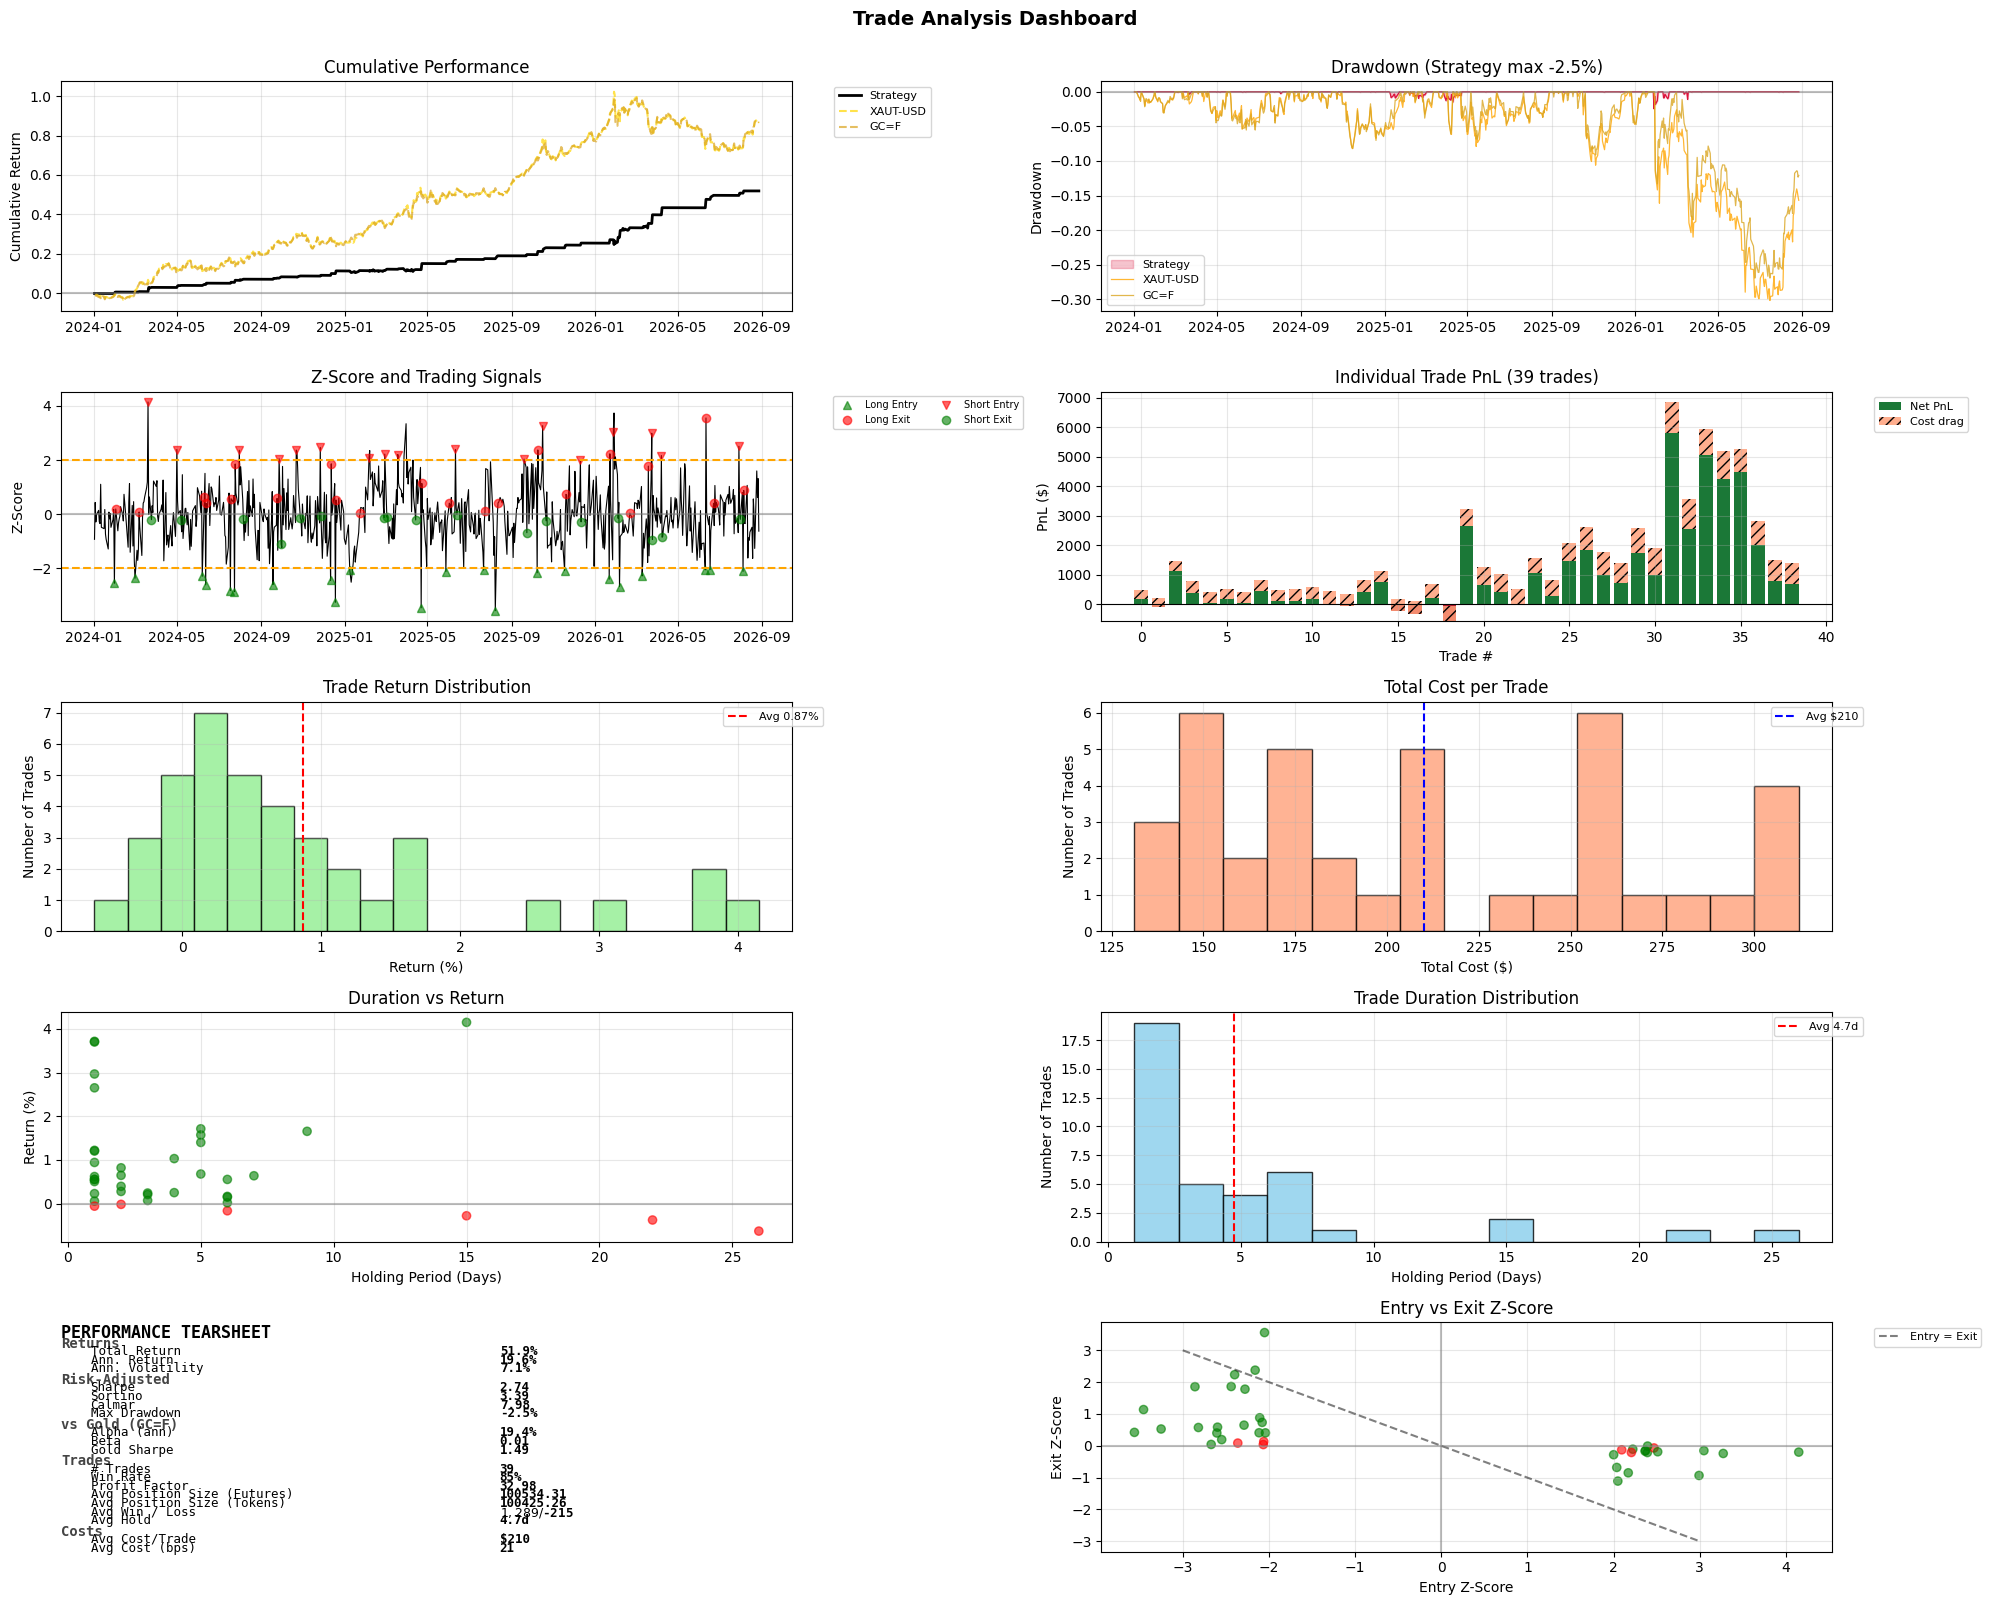

In [37]:
# Trade analysis dashboard
# Enhanced Trade Analysis Dashboard (refactored)
fig, axs = plt.subplots(5, 2, figsize=(20, 16))

el = (df['Position']==1)&(df['Position'].shift(1)==0);  es = (df['Position']==-1)&(df['Position'].shift(1)==0)
xl = (df['Position']==0)&(df['Position'].shift(1)==1);  xs = (df['Position']==0)&(df['Position'].shift(1)==-1)
strat_cum = df['Strategy_Return'].cumsum()               # single equity basis for [0,0]+[0,1]+tearsheet

# [0,0] Cumulative performance
axs[0,0].plot(strat_cum, color='black', lw=2, label='Strategy')
axs[0,0].plot(df['Cumulative_Asset_A'], color='gold',      ls='--', alpha=.7, label=asset_A)
axs[0,0].plot(df['Cumulative_Asset_B'], color='goldenrod', ls='--', alpha=.7, label=asset_B)
axs[0,0].axhline(0, color='gray', alpha=.5); axs[0,0].set_title('Cumulative Performance')
axs[0,0].set_ylabel('Cumulative Return'); axs[0,0].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05,1)); axs[0,0].grid(alpha=.3)

# [0,1] Drawdown
dd = strat_cum - strat_cum.cummax()

# Asset drawdowns, measured from each asset's running peak
asset_a_cum = df['Cumulative_Asset_A']
asset_b_cum = df['Cumulative_Asset_B']

ad = asset_a_cum - asset_a_cum.cummax()
bd = asset_b_cum - asset_b_cum.cummax()

axs[0,1].fill_between(
    dd.index, dd, 0,
    color='crimson', alpha=.25, label='Strategy'
)
axs[0,1].plot(dd.index, dd, color='crimson', lw=.9)

axs[0,1].plot(
    ad.index, ad,
    color='orange', lw=.9, alpha=.8, label=asset_A
)
axs[0,1].plot(
    bd.index, bd,
    color='goldenrod', lw=.9, alpha=.8, label=asset_B
)

axs[0,1].axhline(0, color='gray', alpha=.5)
axs[0,1].set_title(
    f'Drawdown (Strategy max {dd.min() * 100:.1f}%)'
)
axs[0,1].set_ylabel('Drawdown')
axs[0,1].legend(fontsize=8)
axs[0,1].grid(alpha=.3)

# [1,0] Z-score and signals
axs[1,0].plot(df['Z-Score'], color='black', lw=.8, zorder=2)
axs[1,0].plot(df.index, np.where(el, df['Z-Score'], np.nan), '^', color='green', ms=6, alpha=.6, label='Long Entry')
axs[1,0].plot(df.index, np.where(xl, df['Z-Score'], np.nan), 'o', color='red',   ms=6, alpha=.6, label='Long Exit')
axs[1,0].plot(df.index, np.where(es, df['Z-Score'], np.nan), 'v', color='red',   ms=6, alpha=.6, label='Short Entry')
axs[1,0].plot(df.index, np.where(xs, df['Z-Score'], np.nan), 'o', color='green', ms=6, alpha=.6, label='Short Exit')
axs[1,0].axhline(entry_threshold, color='orange', ls='--'); axs[1,0].axhline(-entry_threshold, color='orange', ls='--')
axs[1,0].axhline(0, color='gray', alpha=.5); axs[1,0].set_title('Z-Score and Trading Signals')
axs[1,0].set_ylabel('Z-Score'); axs[1,0].legend(loc='upper left', fontsize=7, ncol=2, framealpha=.9, bbox_to_anchor=(1.05,1)); axs[1,0].grid(alpha=.3)

# [1,1] Individual trade PnL in $ (net + cost stacked = gross)
net = trades_df['net_pnl_after_costs']; cost = trades_df['total_slippage'] + trades_df['total_fees']; x = range(len(trades_df))
axs[1,1].bar(x, net, color=['#1b7837' if v>0 else '#b2182b' for v in net], label='Net PnL')
axs[1,1].bar(x, cost, bottom=net, color='lightsalmon', alpha=.85, hatch='///', label='Cost drag')
axs[1,1].axhline(0, color='black', lw=.8); axs[1,1].set_title(f'Individual Trade PnL ({len(trades_df)} trades)')
axs[1,1].set_xlabel('Trade #'); axs[1,1].set_ylabel('PnL ($)'); axs[1,1].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05,1)); axs[1,1].grid(alpha=.3)

# [2,0] Return distribution (counts)
axs[2,0].hist(trades_df['return_pct'], bins=20, color='lightgreen', alpha=.8, edgecolor='black')
axs[2,0].axvline(trades_df['return_pct'].mean(), color='red', ls='--', label=f"Avg {trades_df['return_pct'].mean():.2f}%")
axs[2,0].set_title('Trade Return Distribution'); axs[2,0].set_xlabel('Return (%)'); axs[2,0].set_ylabel('Number of Trades')
axs[2,0].legend(fontsize=8, bbox_to_anchor=(1.05,1)); axs[2,0].grid(alpha=.3)

# [2,1] Cost distribution (counts)
axs[2,1].hist(trades_df['total_costs'], bins=15, color='lightsalmon', alpha=.8, edgecolor='black')
axs[2,1].axvline(trades_df['total_costs'].mean(), color='blue', ls='--', label=f"Avg ${trades_df['total_costs'].mean():,.0f}")
axs[2,1].set_title('Total Cost per Trade'); axs[2,1].set_xlabel('Total Cost ($)'); axs[2,1].set_ylabel('Number of Trades')
axs[2,1].legend(fontsize=8, bbox_to_anchor=(1.05,1)); axs[2,1].grid(alpha=.3)

# [3,0] Duration vs return
axs[3,0].scatter(trades_df['holding_period'], trades_df['return_pct'],
                 c=['green' if v>0 else 'red' for v in trades_df['return_pct']], alpha=.6)
axs[3,0].axhline(0, color='gray', alpha=.5); axs[3,0].set_xlabel('Holding Period (Days)')
axs[3,0].set_ylabel('Return (%)'); axs[3,0].set_title('Duration vs Return'); axs[3,0].grid(alpha=.3)

# [3,1] Duration distribution (counts)
axs[3,1].hist(trades_df['holding_period'], bins=15, color='skyblue', alpha=.8, edgecolor='black')
axs[3,1].axvline(trades_df['holding_period'].mean(), color='red', ls='--', label=f"Avg {trades_df['holding_period'].mean():.1f}d")
axs[3,1].set_title('Trade Duration Distribution'); axs[3,1].set_xlabel('Holding Period (Days)'); axs[3,1].set_ylabel('Number of Trades')
axs[3,1].legend(fontsize=8, bbox_to_anchor=(1.05,1)); axs[3,1].grid(alpha=.3)

# [4,0] Tearsheet
ax = axs[4,0]; ax.axis('off')
tot_lines = 1 + sum(1 + len(r) for r in metrics.values()); dy = .94/max(tot_lines,1); yv = .99
ax.text(0, yv, 'PERFORMANCE TEARSHEET', fontsize=12, fontweight='bold', va='top', family='monospace'); yv -= dy*1.4
for sec, rows in metrics.items():
    ax.text(0, yv, sec, fontsize=10, fontweight='bold', va='top', family='monospace', color='#444'); yv -= dy
    for k, v in rows:
        ax.text(.04, yv, k, fontsize=9, va='top', family='monospace')
        ax.text(.60, yv, v, fontsize=9, va='top', family='monospace', fontweight='bold'); yv -= dy
    yv -= dy*.2

# [4,1] Entry vs exit z-score
axs[4,1].scatter(trades_df['entry_zscore'], trades_df['exit_zscore'],
                 c=['green' if v>0 else 'red' for v in trades_df['net_pnl_after_costs']], alpha=.6)
axs[4,1].plot([-3,3], [3,-3], 'k--', alpha=.5, label='Entry = Exit')
axs[4,1].axhline(0, color='gray', alpha=.5); axs[4,1].axvline(0, color='gray', alpha=.5)
axs[4,1].set_xlabel('Entry Z-Score'); axs[4,1].set_ylabel('Exit Z-Score'); axs[4,1].set_title('Entry vs Exit Z-Score')
axs[4,1].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05,1)); axs[4,1].grid(alpha=.3)


plt.suptitle('Trade Analysis Dashboard', fontsize=14, fontweight='bold',y = 1)
plt.tight_layout(); plt.show()

Validation - Walk Forward + Monte Carlo Simulation

In [38]:
# --- Reusable validation functions -------------------------------------------
from scipy.optimize import minimize_scalar
val_slippage = SlippageModel(min_slippage_bps=1.0)

# OU fit (exact AR(1) discretisation) + Zeng-Lee conventional-rule entry threshold
def fit_ou(s):
    s = s.dropna(); x0, x1 = s.values[:-1], s.values[1:]
    B, A = np.polyfit(x0, x1, 1); mu = -np.log(B); theta = A/(1-B)
    resid = x1 - (A + B*x0); sigma = np.sqrt(resid.var(ddof=2)*2*mu/(1-B**2))
    return dict(mu=mu, theta=theta, sigma=sigma, sig_eq=sigma/np.sqrt(2*mu), half_life=np.log(2)/mu)

def _S(z, nt=200, tol=1e-16):
    term = np.sqrt(2*np.pi)*z; s = term
    for k in range(1, nt):
        term *= (2*k-1)*z*z/((2*k+1)*(2*k)); s += term
        if abs(term) < tol*abs(s): break
    return s

def zeng_lee_entry(ou, roundtrip_cost):
    mu, sig_eq = ou['mu'], ou['sig_eq']; c_d = roundtrip_cost/sig_eq
    ET = lambda a, b: (_S(a)-_S(b))/(2*mu)
    f  = lambda a: -((a-c_d)/ET(a, 0)) if a > c_d else 1e9   # exit at mean (conventional)
    a_d = minimize_scalar(f, bounds=(0.05, 6), method='bounded').x
    return a_d, ET(a_d, 0)

# streamlined, faithful re-implementation of the cell-23 dollar economics (so it can
# run per-window and on synthetic paths). Same cost knobs as the main backtest.
VCFG = dict(fut_size=10, n_contracts=3, token_fee=0.001, fut_fee=1.5,
            tok_bps=10.0, fut_bps=1.0, fb_tok_vol=50e6, fb_fut_vol=500e6)

def _scaled_dollar_spread(price_series, asset_df, target_bps):
    cs = corwin_schultz_spread(asset_df, absolute=True, agg="rolling", window=window).reindex(price_series.index).ffill()
    if cs.notna().sum() == 0 or cs.mean() == 0: cs = pd.Series(target_bps/1e4, index=price_series.index)
    else: cs = cs/cs.mean()*(target_bps/1e4)
    return cs*price_series

def run_pair_backtest(prices, beta, z, positions, data, cfg=VCFG):
    """Return (trades_df, daily_ret). prices: DataFrame[asset_A, asset_B]; beta: Series; data: {asset: OHLCV}."""
    A, B = asset_A, asset_B; pa, pb = prices[A], prices[B]
    sa = _scaled_dollar_spread(pa, data[A], cfg['tok_bps']); sb = _scaled_dollar_spread(pb, data[B], cfg['fut_bps'])
    fut_oz = cfg['n_contracts']*cfg['fut_size']; idxs = prices.index
    def impact(price, notional, dv):
        try: imp = val_slippage.estimate_slippage(price, abs(notional)/price, dv, None, 0.0)
        except Exception: imp = price*1e-4
        return float(imp if imp > 0 else price*1e-4)
    def execp(mid, side, spr, imp): return mid + spr/2 + imp if side == 'buy' else mid - spr/2 - imp
    trades = []; cur = None
    for i in range(1, len(prices)):
        cp, pp = positions[i], positions[i-1]; date = idxs[i]
        if pp == 0 and cp != 0:
            aA, aB = pa.iloc[i], pb.iloc[i]; bv = float(beta.iloc[i]) if hasattr(beta, 'iloc') else float(beta)
            tok_oz = fut_oz*abs(bv); nA = tok_oz*aA
            spA = sa.iloc[i] if date in sa.index else aA*1e-3; spB = sb.iloc[i] if date in sb.index else aB*1e-3
            iA = impact(aA, nA, cfg['fb_tok_vol']); iB = impact(aB, fut_oz*aB, cfg['fb_fut_vol']); long = cp == 1
            cur = dict(entry_date=date, direction='long' if long else 'short', entry_zscore=z[i], tok_oz=tok_oz,
                       eA=execp(aA, 'buy' if long else 'sell', spA, iA), eB=execp(aB, 'sell' if long else 'buy', spB, iB),
                       nA=abs(nA), ef=cfg['token_fee']*abs(execp(aA,'buy' if long else 'sell',spA,iA)*tok_oz)+cfg['fut_fee']*cfg['n_contracts'])
        elif pp != 0 and cp == 0 and cur is not None:
            aA, aB = pa.iloc[i], pb.iloc[i]; tok_oz = cur['tok_oz']
            spA = sa.iloc[i] if date in sa.index else aA*1e-3; spB = sb.iloc[i] if date in sb.index else aB*1e-3
            iA = impact(aA, tok_oz*aA, cfg['fb_tok_vol']); iB = impact(aB, fut_oz*aB, cfg['fb_fut_vol']); long = cur['direction'] == 'long'
            xA = execp(aA, 'sell' if long else 'buy', spA, iA); xB = execp(aB, 'buy' if long else 'sell', spB, iB)
            pnl = (xA-cur['eA'])*tok_oz + (cur['eB']-xB)*fut_oz if long else (cur['eA']-xA)*tok_oz + (xB-cur['eB'])*fut_oz
            fees = cur['ef'] + cfg['token_fee']*abs(xA*tok_oz) + cfg['fut_fee']*cfg['n_contracts']; net = pnl-fees
            trades.append(dict(entry_date=cur['entry_date'], exit_date=date, direction=cur['direction'],
                entry_zscore=cur['entry_zscore'], exit_zscore=z[i], holding_period=(date-cur['entry_date']).days,
                net_pnl=pnl, total_fees=fees, total_slippage=0.0, total_costs=fees, net_pnl_after_costs=net,
                entry_value=cur['nA'], return_pct=net/cur['nA']*100 if cur['nA'] else np.nan)); cur = None
    trades_df = pd.DataFrame(trades)
    rA, rB = pa.pct_change(), pb.pct_change(); pos = pd.Series(positions, index=prices.index)
    bser = beta.reindex(prices.index) if hasattr(beta, 'reindex') else beta
    dr = pos.shift(1).fillna(0)*(rA - bser*rB) - slippage_const*pos.diff().abs().fillna(0)
    return trades_df, dr.fillna(0)

def metrics_from_daily(dr, ann=252):
    dr = dr.dropna()
    if len(dr) == 0 or dr.std() == 0: return {}
    eq = dr.cumsum(); dn = dr[dr < 0].std()
    return dict(total=dr.sum()*100, sharpe=dr.mean()/dr.std()*np.sqrt(ann),
                sortino=(dr.mean()/dn*np.sqrt(ann)) if dn > 0 else np.nan,
                vol=dr.std()*np.sqrt(ann)*100, maxdd=(eq-eq.cummax()).min()*100)
print("Validation functions loaded.")


Validation functions loaded.


In [39]:
# --- Walk-forward: fit train-only, trade OOS, stitch -------------------------
def walk_forward(data, formation=252, test=126, purge=None, roundtrip_cost=1.0):
    if purge is None: purge = window
    A, B = asset_A, asset_B
    idx = data[A].index.intersection(data[B].index).sort_values()
    oos_trades, oos_daily, folds = [], [], []
    t0 = fold = 0
    while t0 + formation + purge + test <= len(idx):
        tr = idx[t0:t0+formation]
        te = idx[t0+formation+purge : t0+formation+purge+test]
        # fit on TRAIN ONLY
        data_tr = {A: data[A].loc[tr], B: data[B].loc[tr]}
        sp_tr, beta_tr = compute_spread(data_tr, A, B, beta=beta_adj, debug=False)
        ou = fit_ou(sp_tr); a_d, ET = zeng_lee_entry(ou, roundtrip_cost); beta_val = float(beta_tr.iloc[-1])
        # apply to TEST (standardise with TRAIN theta/sig_eq -> no leak)
        data_te = {A: data[A].loc[te], B: data[B].loc[te]}
        sp_te = data_te[A]['Close'] - beta_val*data_te[B]['Close']
        z_te = ((sp_te - ou['theta'])/ou['sig_eq']).values
        pos = generate_positions(z_te, a_d, 0.0)          # entry ±a_d, exit at mean
        prices = pd.DataFrame({A: data_te[A]['Close'], B: data_te[B]['Close']})
        tdf, dr = run_pair_backtest(prices, pd.Series(beta_val, index=te), z_te, pos, data_te)
        if len(tdf): oos_trades.append(tdf)
        oos_daily.append(dr)
        folds.append(dict(fold=fold, train=f"{tr[0].date()}..{tr[-1].date()}",
            test=f"{te[0].date()}..{te[-1].date()}", entry_z=round(a_d,2),
            half_life=round(ou['half_life'],1), beta=round(beta_val,3), n_trades=len(tdf)))
        t0 += test; fold += 1
    oos_trades = pd.concat(oos_trades, ignore_index=True) if oos_trades else pd.DataFrame()
    oos_daily  = pd.concat(oos_daily).sort_index()
    return oos_trades, oos_daily, pd.DataFrame(folds)

# formation ~1y, test ~6m, purge = z-score window
oos_trades, oos_daily, folds = walk_forward(data_weekdays, formation=252, test=126, roundtrip_cost=1.0)
oos = metrics_from_daily(oos_daily)

# in-sample (optimistic) reference: fit on full history, trade full history
_sp = data_weekdays[asset_A]['Close'] - data_weekdays[asset_B]['Close']
_ou = fit_ou(_sp); _ad, _ = zeng_lee_entry(_ou, 1.0)
_z = ((_sp - _ou['theta'])/_ou['sig_eq']).values
_pos = generate_positions(_z, _ad, 0.0)
_prices = pd.DataFrame({asset_A: data_weekdays[asset_A]['Close'], asset_B: data_weekdays[asset_B]['Close']})
_, _dr = run_pair_backtest(_prices, pd.Series(1.0, index=_prices.index), _z, _pos, data_weekdays)
insample = metrics_from_daily(_dr)

print(folds.to_string(index=False)); print()
print(f"{'metric':<12}{'in-sample':>12}{'walk-fwd OOS':>14}")
for k in ['sharpe','sortino','total','maxdd','vol']:
    print(f"{k:<12}{insample.get(k,float('nan')):>12.2f}{oos.get(k,float('nan')):>14.2f}")
print(f"\nOOS trades: {len(oos_trades)}   (the Sharpe drop from in-sample -> OOS is the overfit gap)")


 fold                  train                   test  entry_z  half_life  beta  n_trades
    0 2020-02-07..2021-02-05 2021-03-09..2021-09-03     0.58        1.3   1.0         5
    1 2020-08-07..2021-08-06 2021-09-07..2022-03-07     0.65        0.9   1.0         9
    2 2021-02-08..2022-02-04 2022-03-08..2022-09-06     0.77        0.5   1.0        17
    3 2021-08-09..2022-08-08 2022-09-07..2023-03-08     0.73        1.0   1.0        10
    4 2022-02-07..2023-02-07 2023-03-09..2023-09-07     0.70        1.3   1.0        10
    5 2022-08-09..2023-08-09 2023-09-08..2024-03-08     0.77        1.1   1.0        11
    6 2023-02-08..2024-02-08 2024-03-11..2024-09-09     0.82        0.4   1.0        19
    7 2023-08-10..2024-08-09 2024-09-10..2025-03-11     0.77        0.3   1.0        20
    8 2024-02-09..2025-02-10 2025-03-12..2025-09-09     0.65        1.4   1.0        19
    9 2024-08-12..2025-08-11 2025-09-10..2026-03-11     0.57        1.0   1.0        29

metric         in-sample  walk-

In [40]:
# --- Monte Carlo: bootstrap OOS + OU-simulated paths ------------------------
ANN = 252
def block_bootstrap(series, block=10, n_paths=4000, out_len=None):
    x = series.dropna().values; n = len(x); out_len = out_len or n
    out = np.empty((n_paths, out_len))
    for p in range(n_paths):
        chunks, tot = [], 0
        while tot < out_len:
            s = np.random.randint(0, max(1, n-block)); chunks.append(x[s:s+block]); tot += block
        out[p] = np.concatenate(chunks)[:out_len]
    return out

def path_metrics(mat):
    sh  = mat.mean(1)/mat.std(1)*np.sqrt(ANN)
    tot = mat.sum(1)*100
    eq  = np.cumsum(mat, 1); mdd = (eq - np.maximum.accumulate(eq, 1)).min(1)*100
    return sh, tot, mdd

# (A) bootstrap the OOS daily returns
bp = block_bootstrap(oos_daily, block=10, n_paths=4000)
sh_b, tot_b, mdd_b = path_metrics(bp)

# (B) simulate OU spread paths (params fit on full history) and re-run the strategy
ou_full = fit_ou(_sp); a_d_full, _ = zeng_lee_entry(ou_full, 1.0)
def simulate_ou(ou, L, n):
    mu, th, sg = ou['mu'], ou['theta'], ou['sigma']; B = np.exp(-mu)
    P = np.empty((n, L)); P[:, 0] = th
    for t in range(1, L):
        P[:, t] = th + B*(P[:, t-1]-th) + sg*np.sqrt((1-B**2)/(2*mu))*np.random.randn(n)
    return P
paths = simulate_ou(ou_full, len(oos_daily), 2000)
sim_sh, sim_tot, sim_mdd = [], [], []
for p in paths:
    z = (p - ou_full['theta'])/ou_full['sig_eq']
    pos = pd.Series(generate_positions(z, a_d_full, 0.0))
    dr = pos.shift(1).fillna(0)*pd.Series(p).diff()/np.maximum(np.abs(p), 1e-9)
    dr = dr - slippage_const*pos.diff().abs().fillna(0)
    m = metrics_from_daily(dr.fillna(0))
    if m: sim_sh.append(m['sharpe']); sim_tot.append(m['total']); sim_mdd.append(m['maxdd'])
sim_sh, sim_tot, sim_mdd = map(np.array, (sim_sh, sim_tot, sim_mdd))

pct_rank = lambda dist, v: float((dist < v).mean()*100)
print("Bootstrap Sharpe 5/50/95:", np.percentile(sh_b, [5,50,95]).round(2),
      "| real OOS", round(oos['sharpe'],2), "at", round(pct_rank(sh_b, oos['sharpe'])),"pctile")
print("P(Sharpe<=0):", round((sh_b<=0).mean()*100,1),"%   OU-sim Sharpe median:", round(np.median(sim_sh),2))


Bootstrap Sharpe 5/50/95: [2.99 3.47 3.99] | real OOS 3.49 at 52 pctile
P(Sharpe<=0): 0.0 %   OU-sim Sharpe median: 1.89


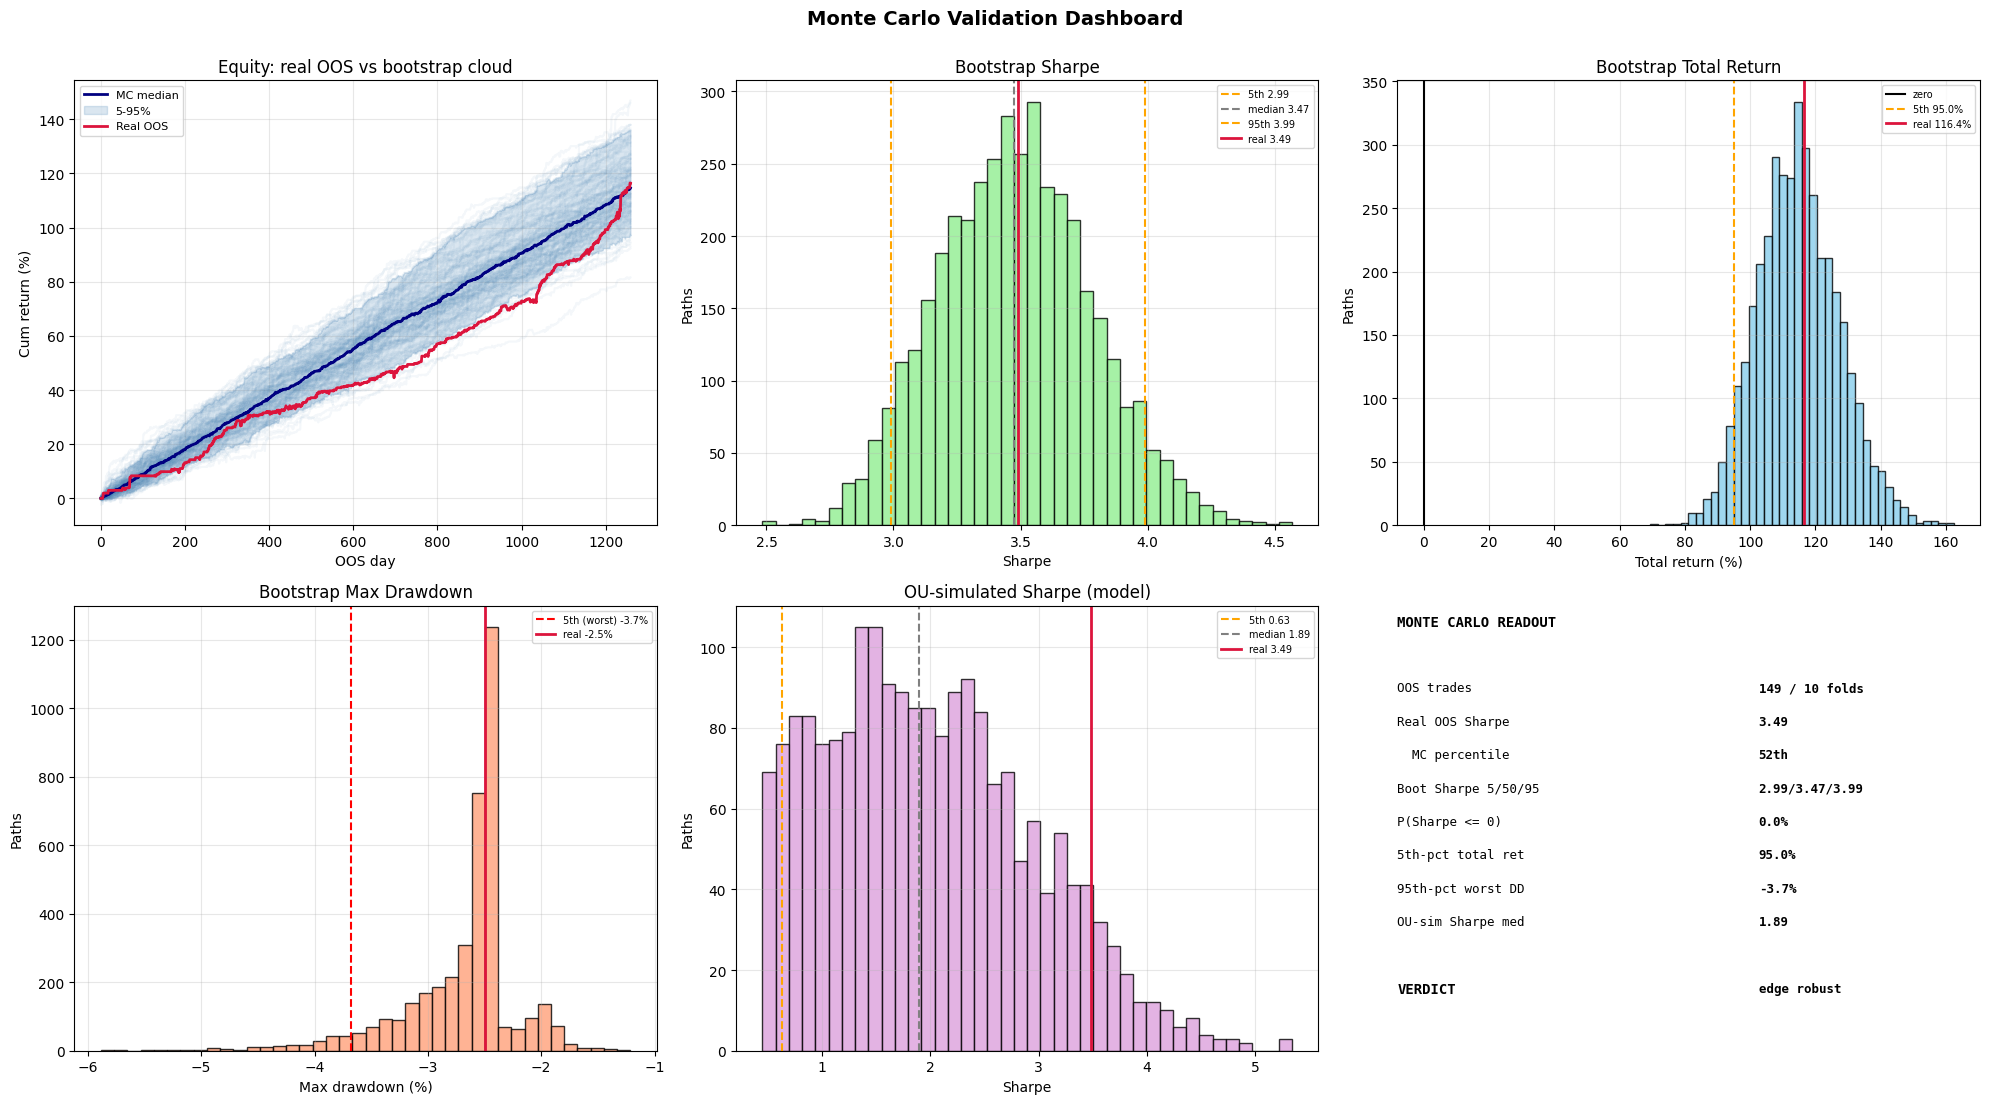

In [41]:
# --- Monte Carlo dashboard ---------------------------------------------------
p5, p50, p95 = np.percentile(sh_b, [5,50,95])
fig, axs = plt.subplots(2, 3, figsize=(20, 11))

eq_real = oos_daily.cumsum()*100
cum = np.cumsum(block_bootstrap(oos_daily, 10, 120, out_len=len(oos_daily)), 1)*100
for c in cum: axs[0,0].plot(c, color='steelblue', alpha=.06)
axs[0,0].plot(np.percentile(cum,50,0), color='navy', lw=2, label='MC median')
axs[0,0].fill_between(range(cum.shape[1]), np.percentile(cum,5,0), np.percentile(cum,95,0), color='steelblue', alpha=.2, label='5-95%')
axs[0,0].plot(np.arange(len(eq_real)), eq_real.values, color='crimson', lw=2, label='Real OOS')
axs[0,0].set_title('Equity: real OOS vs bootstrap cloud'); axs[0,0].set_xlabel('OOS day'); axs[0,0].set_ylabel('Cum return (%)'); axs[0,0].legend(fontsize=8); axs[0,0].grid(alpha=.3)

axs[0,1].hist(sh_b, bins=40, color='lightgreen', edgecolor='black', alpha=.8)
for q,c,l in [(p5,'orange','5th'),(p50,'gray','median'),(p95,'orange','95th')]: axs[0,1].axvline(q, color=c, ls='--', label=f'{l} {q:.2f}')
axs[0,1].axvline(oos['sharpe'], color='crimson', lw=2, label=f"real {oos['sharpe']:.2f}")
axs[0,1].set_title('Bootstrap Sharpe'); axs[0,1].set_xlabel('Sharpe'); axs[0,1].set_ylabel('Paths'); axs[0,1].legend(fontsize=7); axs[0,1].grid(alpha=.3)

axs[0,2].hist(tot_b, bins=40, color='skyblue', edgecolor='black', alpha=.8)
axs[0,2].axvline(0, color='black', lw=1.5, label='zero')
axs[0,2].axvline(np.percentile(tot_b,5), color='orange', ls='--', label=f'5th {np.percentile(tot_b,5):.1f}%')
axs[0,2].axvline(oos['total'], color='crimson', lw=2, label=f"real {oos['total']:.1f}%")
axs[0,2].set_title('Bootstrap Total Return'); axs[0,2].set_xlabel('Total return (%)'); axs[0,2].set_ylabel('Paths'); axs[0,2].legend(fontsize=7); axs[0,2].grid(alpha=.3)

axs[1,0].hist(mdd_b, bins=40, color='lightsalmon', edgecolor='black', alpha=.8)
axs[1,0].axvline(np.percentile(mdd_b,5), color='red', ls='--', label=f'5th (worst) {np.percentile(mdd_b,5):.1f}%')
axs[1,0].axvline(oos['maxdd'], color='crimson', lw=2, label=f"real {oos['maxdd']:.1f}%")
axs[1,0].set_title('Bootstrap Max Drawdown'); axs[1,0].set_xlabel('Max drawdown (%)'); axs[1,0].set_ylabel('Paths'); axs[1,0].legend(fontsize=7); axs[1,0].grid(alpha=.3)

axs[1,1].hist(sim_sh, bins=40, color='plum', edgecolor='black', alpha=.8)
axs[1,1].axvline(np.percentile(sim_sh,5), color='orange', ls='--', label=f'5th {np.percentile(sim_sh,5):.2f}')
axs[1,1].axvline(np.median(sim_sh), color='gray', ls='--', label=f'median {np.median(sim_sh):.2f}')
axs[1,1].axvline(oos['sharpe'], color='crimson', lw=2, label=f"real {oos['sharpe']:.2f}")
axs[1,1].set_title('OU-simulated Sharpe (model)'); axs[1,1].set_xlabel('Sharpe'); axs[1,1].set_ylabel('Paths'); axs[1,1].legend(fontsize=7); axs[1,1].grid(alpha=.3)

ax = axs[1,2]; ax.axis('off')
rank = pct_rank(sh_b, oos['sharpe']); p_neg = (sh_b<=0).mean()*100
rows = [('MONTE CARLO READOUT',''), ('',''),
 ('OOS trades', f"{len(oos_trades)} / {len(folds)} folds"),
 ('Real OOS Sharpe', f"{oos['sharpe']:.2f}"),
 ('  MC percentile', f"{rank:.0f}th"),
 ('Boot Sharpe 5/50/95', f"{p5:.2f}/{p50:.2f}/{p95:.2f}"),
 ('P(Sharpe <= 0)', f"{p_neg:.1f}%"),
 ('5th-pct total ret', f"{np.percentile(tot_b,5):.1f}%"),
 ('95th-pct worst DD', f"{np.percentile(mdd_b,5):.1f}%"),
 ('OU-sim Sharpe med', f"{np.median(sim_sh):.2f}"), ('',''),
 ('VERDICT', 'edge robust' if (p5 > 0 and p_neg < 5) else 'fragile / noise-like')]
y = .98
for k, v in rows:
    fw = 'bold' if k in ('MONTE CARLO READOUT','VERDICT') else 'normal'
    ax.text(0, y, k, fontsize=10 if fw=='bold' else 9, family='monospace', fontweight=fw, va='top')
    ax.text(.62, y, v, fontsize=9, family='monospace', fontweight='bold', va='top'); y -= .075

plt.suptitle('Monte Carlo Validation Dashboard', fontsize=14, fontweight='bold',y = 1)
plt.tight_layout(); plt.show()


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

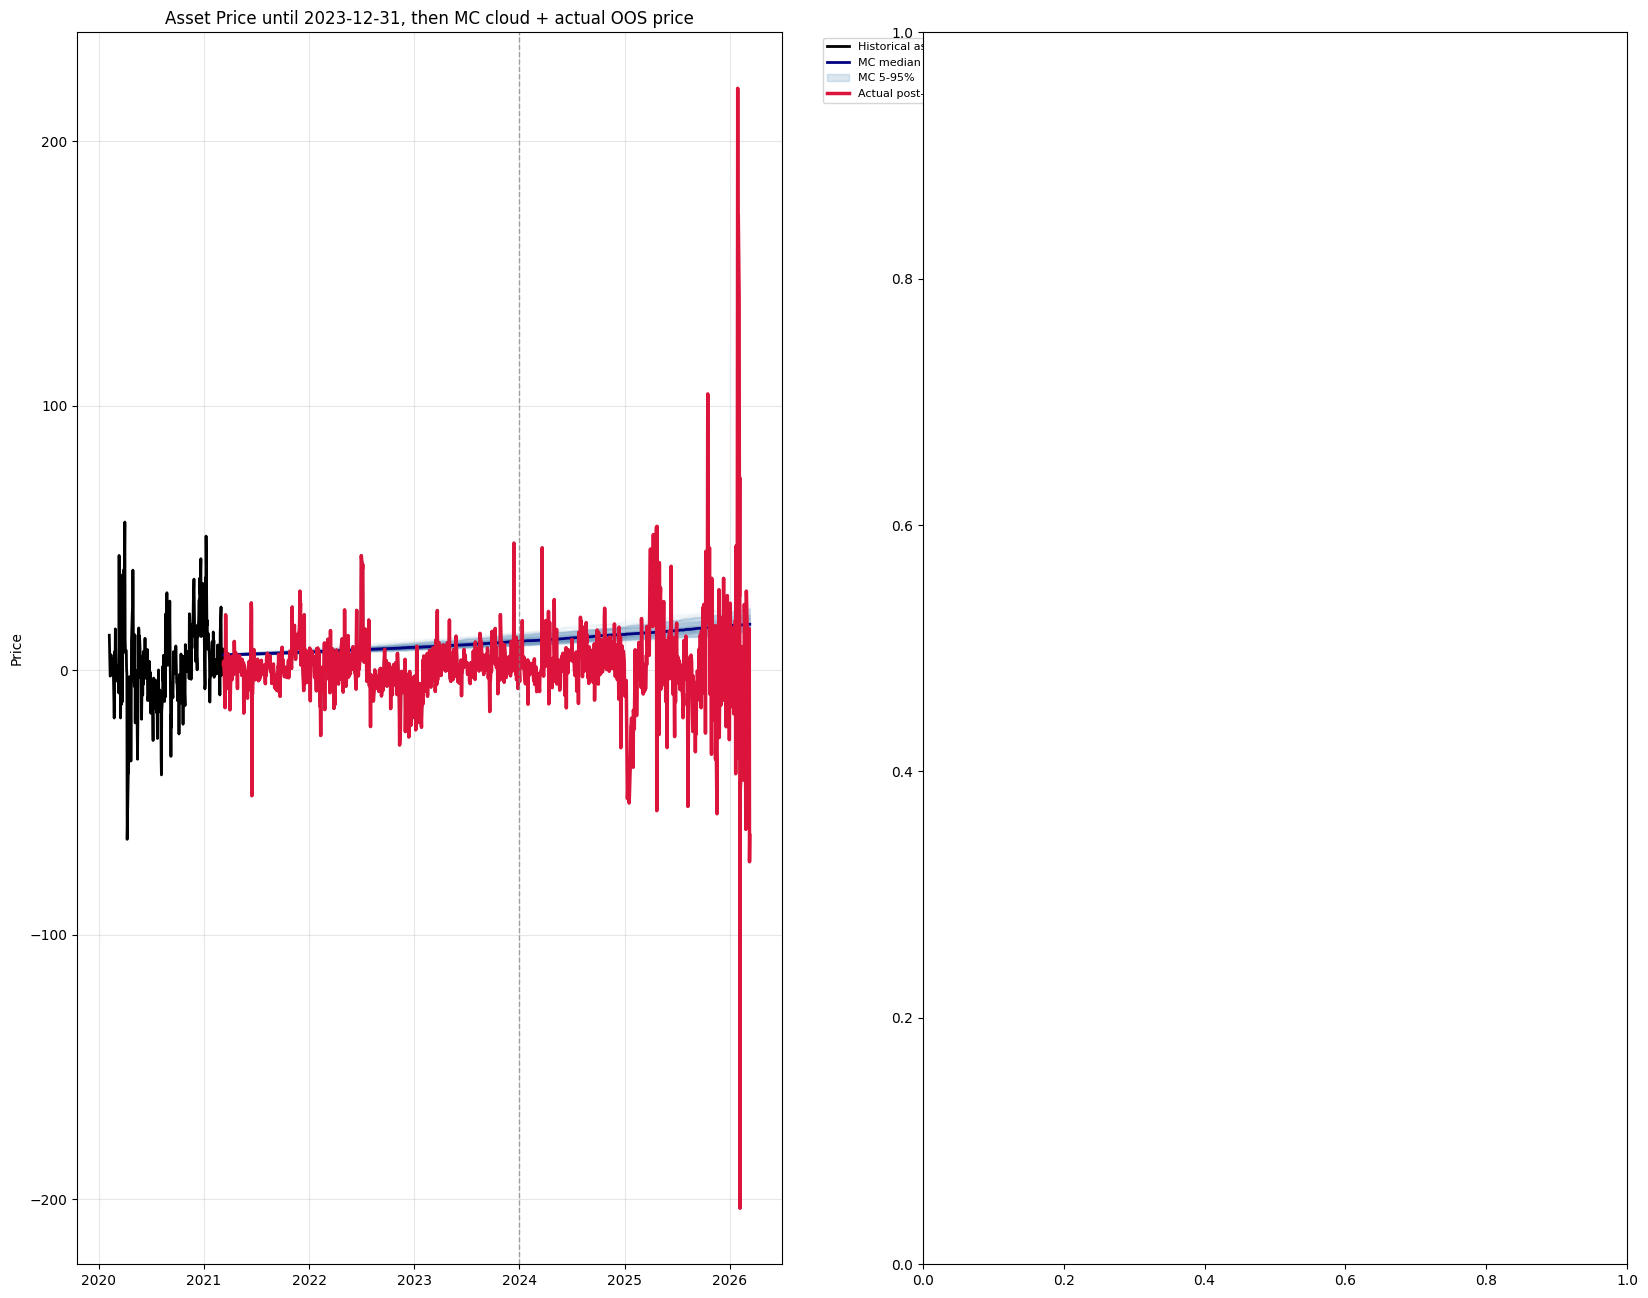

In [42]:

# fig, axs = plt.subplots(1, 2, figsize=(20, 16))

# el = (df['Position']==1)&(df['Position'].shift(1)==0);  es = (df['Position']==-1)&(df['Position'].shift(1)==0)
# xl = (df['Position']==0)&(df['Position'].shift(1)==1);  xs = (df['Position']==0)&(df['Position'].shift(1)==-1)
# strat_cum = df['Strategy_Return'].cumsum()

# # [0,0] Cumulative performance + MC cloud
# eq_real = oos_daily.cumsum()*100

# split_date = pd.to_datetime(train_end)
# asset_price = xaut_xau_spread['spread']
# train_price = asset_price.loc[:split_date]
# if train_price.empty:
#     train_price = asset_price.iloc[:1]
# start_price = train_price.iloc[-1]

# oos_dates = oos_daily.index
# oos_price = asset_price.reindex(oos_dates)

# sim_returns = np.array(block_bootstrap(oos_daily, 10, 120, out_len=len(oos_daily))[:500])
# mc_paths = start_price * np.cumprod(1 + sim_returns, axis=1)

fig, axs = plt.subplots(1, 2, figsize=(20, 16))

el = (df['Position']==1)&(df['Position'].shift(1)==0);  es = (df['Position']==-1)&(df['Position'].shift(1)==0)
xl = (df['Position']==0)&(df['Position'].shift(1)==1);  xs = (df['Position']==0)&(df['Position'].shift(1)==-1)
strat_cum = df['Strategy_Return'].cumsum()

# [0,0] Cumulative performance + MC cloud
eq_real = oos_daily.cumsum()*100

split_date = pd.to_datetime(train_end)
asset_price = xaut_xau_spread['spread']
train_price = asset_price.loc[:split_date]
if train_price.empty:
    train_price = asset_price.iloc[:1]
start_price = train_price.iloc[-1]

oos_dates = oos_daily.index
oos_price = asset_price.reindex(oos_dates)

sim_returns = np.array(block_bootstrap(oos_daily, 10, 120, out_len=len(oos_daily))[:500])
mc_paths = start_price * np.cumprod(1 + sim_returns, axis=1)

for path in mc_paths:
    axs[0].plot(oos_dates, path, color='steelblue', alpha=.03)

axs[0].plot(train_price.index, train_price.values, color='black', lw=2, label='Historical asset price')
axs[0].plot(oos_dates, np.percentile(mc_paths, 50, axis=0), color='navy', lw=2, label='MC median')
axs[0].fill_between(oos_dates,
                    np.percentile(mc_paths, 5, axis=0),
                    np.percentile(mc_paths, 95, axis=0),
                    color='steelblue', alpha=.2, label='MC 5-95%')
axs[0].plot(oos_dates, oos_price.values, color='crimson', lw=2.5, label='Actual post-split')

axs[0].axvline(split_date, color='gray', ls='--', lw=1, alpha=.7)
axs[0].set_title(f'Asset Price until {split_date.date()}, then MC cloud + actual OOS price')
axs[0].set_ylabel('Price')
axs[0].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05,1))
axs[0].grid(alpha=.3)

axs[0,0].plot(train_price.index, train_price.values, color='black', lw=2, label='Historical asset price')
axs[0,0].plot(oos_dates, np.percentile(mc_paths, 50, axis=0), color='navy', lw=2, label='MC median')
axs[0,0].fill_between(oos_dates,
                      np.percentile(mc_paths, 5, axis=0),
                      np.percentile(mc_paths, 95, axis=0),
                      color='steelblue', alpha=.2, label='MC 5-95%')
axs[0,0].plot(oos_dates, oos_price.values, color='crimson', lw=2.5, label='Actual post-split')

axs[0,0].axvline(split_date, color='gray', ls='--', lw=1, alpha=.7)
axs[0,0].set_title(f'Asset Price until {split_date.date()}, then MC cloud + actual OOS price')
axs[0,0].set_ylabel('Price')
axs[0,0].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05,1))
axs[0,0].grid(alpha=.3)


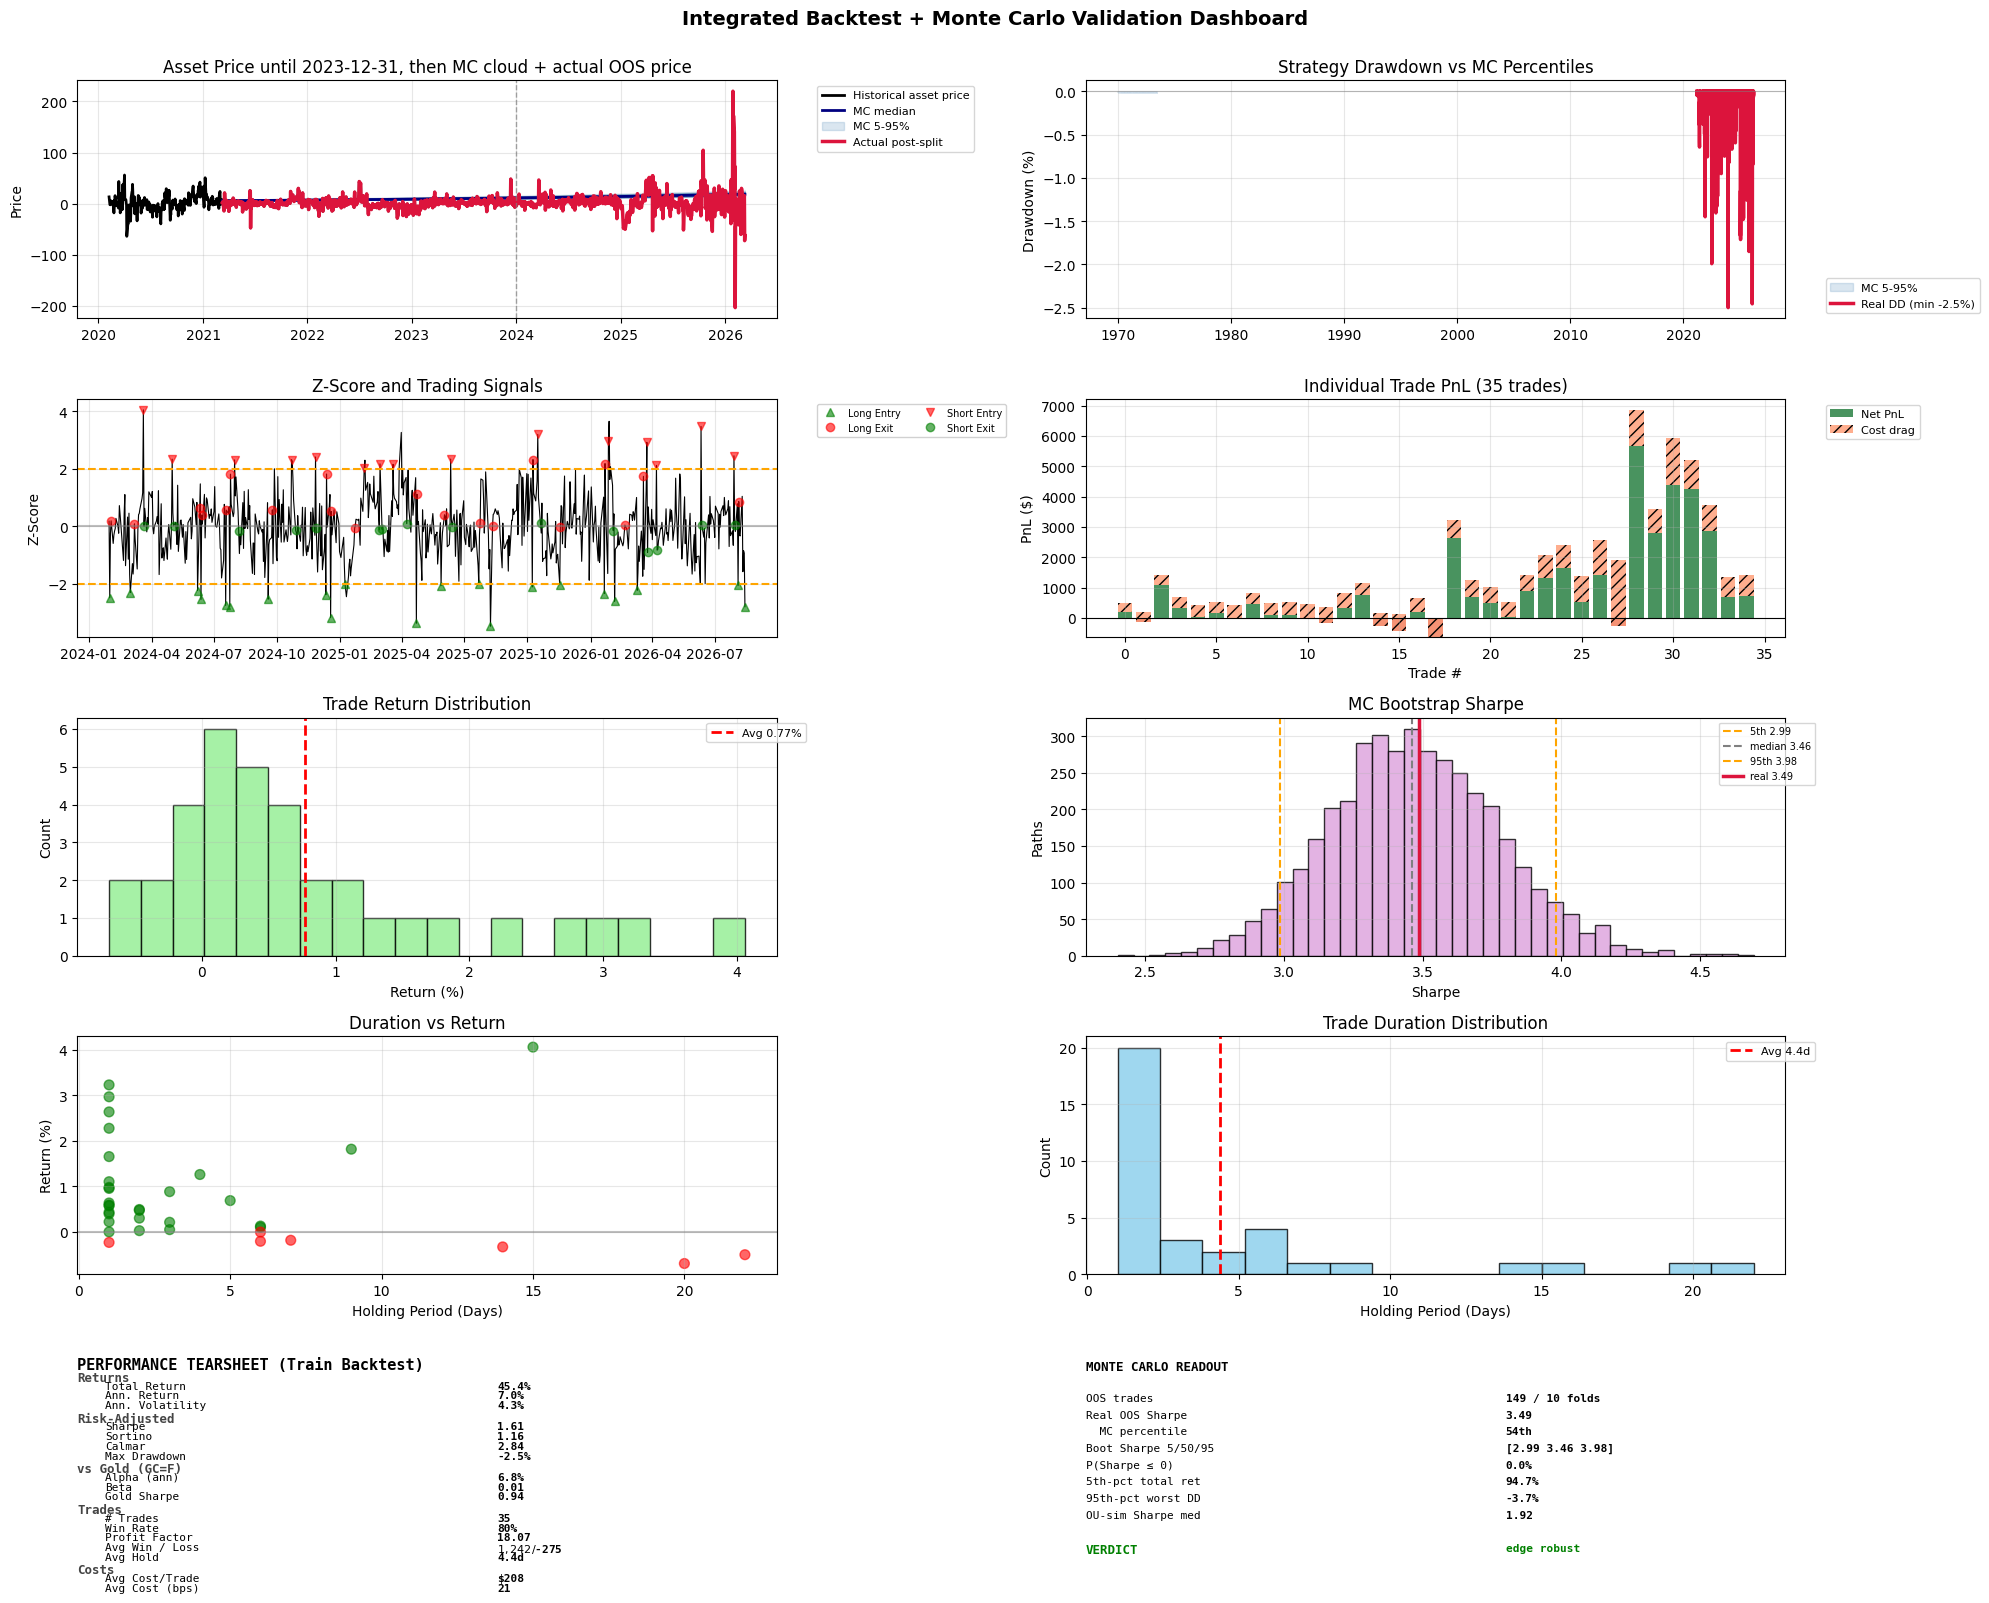

In [ ]:
# Trade Analysis Dashboard + Monte Carlo
# replot equity curves, drawdown etc. but now add monte carlo cloud and OU-simulated median path

fig, axs = plt.subplots(5, 2, figsize=(20, 16))

el = (df['Position']==1)&(df['Position'].shift(1)==0);  es = (df['Position']==-1)&(df['Position'].shift(1)==0)
xl = (df['Position']==0)&(df['Position'].shift(1)==1);  xs = (df['Position']==0)&(df['Position'].shift(1)==-1)
strat_cum = df['Strategy_Return'].cumsum()

# [0,0] Cumulative performance + MC cloud
eq_real = oos_daily.cumsum()*100

split_date = pd.to_datetime(train_end)
asset_price = xaut_xau_spread['spread']
train_price = asset_price.loc[:split_date]
if train_price.empty:
    train_price = asset_price.iloc[:1]
start_price = train_price.iloc[-1]

oos_dates = oos_daily.index
oos_price = asset_price.reindex(oos_dates)

sim_returns = np.array(block_bootstrap(oos_daily, 10, 120, out_len=len(oos_daily))[:500])
mc_paths = start_price * np.cumprod(1 + sim_returns, axis=1)

for path in mc_paths:
    axs[0,0].plot(oos_dates, path, color='steelblue', alpha=.03)

axs[0,0].plot(train_price.index, train_price.values, color='black', lw=2, label='Historical asset price')
axs[0,0].plot(oos_dates, np.percentile(mc_paths, 50, axis=0), color='navy', lw=2, label='MC median')
axs[0,0].fill_between(oos_dates,
                      np.percentile(mc_paths, 5, axis=0),
                      np.percentile(mc_paths, 95, axis=0),
                      color='steelblue', alpha=.2, label='MC 5-95%')
axs[0,0].plot(oos_dates, oos_price.values, color='crimson', lw=2.5, label='Actual post-split')

axs[0,0].axvline(split_date, color='gray', ls='--', lw=1, alpha=.7)
axs[0,0].set_title(f'Asset Price until {split_date.date()}, then MC cloud + actual OOS price')
axs[0,0].set_ylabel('Price')
axs[0,0].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05,1))
axs[0,0].grid(alpha=.3)

# [0,1] Drawdown + MC percentiles
dd_real = eq_real - eq_real.cummax()
dd_mc = np.array([np.cumsum(c) - np.maximum.accumulate(np.cumsum(c)) for c in block_bootstrap(oos_daily, 10, 120, out_len=len(oos_daily))[:500]])
axs[0,1].fill_between(range(dd_mc.shape[1]), np.percentile(dd_mc,5,0), np.percentile(dd_mc,95,0), color='steelblue', alpha=.2, label='MC 5-95%')
axs[0,1].plot(dd_real.index, dd_real, color='crimson', lw=2.5, label=f'Real DD (min {dd_real.min():.1f}%)')
axs[0,1].axhline(0, color='gray', alpha=.5, lw=.8)
axs[0,1].set_title('Strategy Drawdown vs MC Percentiles'); axs[0,1].set_ylabel('Drawdown (%)'); axs[0,1].legend(loc='lower left', fontsize=8, bbox_to_anchor=(1.05,0)); axs[0,1].grid(alpha=.3)

# [1,0] Z-score and signals (from train backtest)
axs[1,0].plot(df['Z-Score'], color='black', lw=.8, zorder=2)
axs[1,0].plot(df.index, np.where(el, df['Z-Score'], np.nan), '^', color='green', ms=6, alpha=.6, label='Long Entry')
axs[1,0].plot(df.index, np.where(xl, df['Z-Score'], np.nan), 'o', color='red',   ms=6, alpha=.6, label='Long Exit')
axs[1,0].plot(df.index, np.where(es, df['Z-Score'], np.nan), 'v', color='red',   ms=6, alpha=.6, label='Short Entry')
axs[1,0].plot(df.index, np.where(xs, df['Z-Score'], np.nan), 'o', color='green', ms=6, alpha=.6, label='Short Exit')
axs[1,0].axhline(entry_threshold, color='orange', ls='--'); axs[1,0].axhline(-entry_threshold, color='orange', ls='--')
axs[1,0].axhline(0, color='gray', alpha=.5); axs[1,0].set_title('Z-Score and Trading Signals')
axs[1,0].set_ylabel('Z-Score'); axs[1,0].legend(loc='upper left', fontsize=7, ncol=2, framealpha=.9, bbox_to_anchor=(1.05,1)); axs[1,0].grid(alpha=.3)

# [1,1] Individual trade PnL
net = trades_df['net_pnl_after_costs']; cost = trades_df['total_slippage'] + trades_df['total_fees']; x = range(len(trades_df))
axs[1,1].bar(x, net, color=['#1b7837' if v>0 else '#b2182b' for v in net], label='Net PnL', alpha=.8)
axs[1,1].bar(x, cost, bottom=net, color='lightsalmon', alpha=.85, hatch='///', label='Cost drag')
axs[1,1].axhline(0, color='black', lw=.8); axs[1,1].set_title(f'Individual Trade PnL ({len(trades_df)} trades)')
axs[1,1].set_xlabel('Trade #'); axs[1,1].set_ylabel('PnL ($)'); axs[1,1].legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05,1)); axs[1,1].grid(alpha=.3)

# [2,0] Return distribution
axs[2,0].hist(trades_df['return_pct'], bins=20, color='lightgreen', alpha=.8, edgecolor='black')
axs[2,0].axvline(trades_df['return_pct'].mean(), color='red', ls='--', lw=2, label=f"Avg {trades_df['return_pct'].mean():.2f}%")
axs[2,0].set_title('Trade Return Distribution'); axs[2,0].set_xlabel('Return (%)'); axs[2,0].set_ylabel('Count')
axs[2,0].legend(fontsize=8, bbox_to_anchor=(1.05,1)); axs[2,0].grid(alpha=.3)

# [2,1] MC Sharpe distribution
axs[2,1].hist(sh_b, bins=40, color='plum', alpha=.8, edgecolor='black')
for q,c,l in [(np.percentile(sh_b,5),'orange','5th'),(np.median(sh_b),'gray','median'),(np.percentile(sh_b,95),'orange','95th')]:
    axs[2,1].axvline(q, color=c, ls='--', lw=1.5, label=f'{l} {q:.2f}')
axs[2,1].axvline(oos['sharpe'], color='crimson', lw=2.5, label=f"real {oos['sharpe']:.2f}")
axs[2,1].set_title('MC Bootstrap Sharpe'); axs[2,1].set_xlabel('Sharpe'); axs[2,1].set_ylabel('Paths')
axs[2,1].legend(fontsize=7, bbox_to_anchor=(1.05,1)); axs[2,1].grid(alpha=.3)

# [3,0] Duration vs return
axs[3,0].scatter(trades_df['holding_period'], trades_df['return_pct'],
                 c=['green' if v>0 else 'red' for v in trades_df['return_pct']], alpha=.6, s=50)
axs[3,0].axhline(0, color='gray', alpha=.5); axs[3,0].set_xlabel('Holding Period (Days)')
axs[3,0].set_ylabel('Return (%)'); axs[3,0].set_title('Duration vs Return'); axs[3,0].grid(alpha=.3)

# [3,1] Duration distribution
axs[3,1].hist(trades_df['holding_period'], bins=15, color='skyblue', alpha=.8, edgecolor='black')
axs[3,1].axvline(trades_df['holding_period'].mean(), color='red', ls='--', lw=2, label=f"Avg {trades_df['holding_period'].mean():.1f}d")
axs[3,1].set_title('Trade Duration Distribution'); axs[3,1].set_xlabel('Holding Period (Days)'); axs[3,1].set_ylabel('Count')
axs[3,1].legend(fontsize=8, bbox_to_anchor=(1.05,1)); axs[3,1].grid(alpha=.3)

# [4,0] Tearsheet (metrics from main backtest)
ax = axs[4,0]; ax.axis('off')
tot_lines = 1 + sum(1 + len(r) for r in metrics.values()); dy = .94/max(tot_lines,1); yv = .99
ax.text(0, yv, 'PERFORMANCE TEARSHEET (Train Backtest)', fontsize=11, fontweight='bold', va='top', family='monospace'); yv -= dy*1.4
for sec, rows in metrics.items():
    ax.text(0, yv, sec, fontsize=9, fontweight='bold', va='top', family='monospace', color='#444'); yv -= dy
    for k, v in rows:
        ax.text(.04, yv, k, fontsize=8, va='top', family='monospace')
        ax.text(.60, yv, v, fontsize=8, va='top', family='monospace', fontweight='bold'); yv -= dy
    yv -= dy*.2

# [4,1] OOS vs MC verdict
ax = axs[4,1]; ax.axis('off')
rank = pct_rank(sh_b, oos['sharpe']); p_neg = (sh_b<=0).mean()*100
rows = [('MONTE CARLO READOUT',''), ('',''),
 ('OOS trades', f"{len(oos_trades)} / {len(folds)} folds"),
 ('Real OOS Sharpe', f"{oos['sharpe']:.2f}"),
 ('  MC percentile', f"{rank:.0f}th"),
 ('Boot Sharpe 5/50/95', f"{np.percentile(sh_b,[5,50,95]).round(2)}"),
 ('P(Sharpe ≤ 0)', f"{p_neg:.1f}%"),
 ('5th-pct total ret', f"{np.percentile(tot_b,5):.1f}%"),
 ('95th-pct worst DD', f"{np.percentile(mdd_b,5):.1f}%"),
 ('OU-sim Sharpe med', f"{np.median(sim_sh):.2f}"), ('',''),
 ('VERDICT', 'edge robust' if (np.percentile(sh_b,5) > 0 and p_neg < 5) else 'fragile / noise')]
y = .98
for k, v in rows:
    fw = 'bold' if k in ('MONTE CARLO READOUT','VERDICT') else 'normal'
    col = 'green' if 'robust' in str(v) else 'red' if 'fragile' in str(v) else 'black'
    ax.text(0, y, k, fontsize=9 if fw=='bold' else 8, family='monospace', fontweight=fw, va='top', color=col)
    ax.text(.60, y, v, fontsize=8, family='monospace', fontweight='bold', va='top', color=col); y -= .07

plt.suptitle('Integrated Backtest + Monte Carlo Validation Dashboard', fontsize=14, fontweight='bold',y = 1)
plt.tight_layout(); plt.show()
